## Прoценка по местам

## Введение

Необходимо создать модель, определяющее место предложения среди списка конкурентных предложений исходя из цены, остатков, актуальных продаж за последнее время, маржи и других факторов.

## Описание данных

В наличии есть несколько xlsm-файлов образцов с проставленными местами.  
В каждом файле есть много десятков столбцов. Некоторые представляют собой готовые признаки, которые можно использовать. Некоторые содержат промежуточные вычисления в excel и для задачи очевидно не нужны. В некоторых столбцах данные расположены "в ширину", т.е. это по сути строки с повторяющимися типами данных вместо столбцов. Не все столбцы озаглавлены, но есть информация, что где находится.  
Данные необходимо предобработать, привести к виду, подходящему для моделей, обучить несколько видов моделей и выбрать лучшую из них.
    

In [1]:
#pip install xlrd
#pip install openpyxl
#!pip install phik -q 
#!pip install lightgbm 
#pip install optuna
#pip install optuna-integration[sklearn]
#!pip install catboost

## Импорты и объявление переменных

In [2]:
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from optuna import distributions
from optuna.integration import OptunaSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyClassifier
from catboost import CatBoostClassifier
import numpy as np
from sklearn.tree import DecisionTreeClassifier

C:\Users\pogar\anaconda3\envs\practicum\lib\site-packages\sklearn\utils\fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


In [3]:
RANDOM_STATE = 42

In [4]:
offers_num = 12

In [5]:
days_limit = 6 #срок выше которого предложения не рассматриваются

In [6]:
our_logo = "PRQL"

In [7]:
places = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] #места, нужны чтобы привести таблицу из "горизонтального" вида в обычный

In [8]:
places = pd.DataFrame(places)
places.columns = ['place']

In [9]:
#Пояснения по местам
#place - место для соединения двух таблиц, содержит предложения с длинным сроком в том числе
#place_final - порядковое место, без предложений с длинным сроком
#место - исходное место нашего предложения, предложения с длинным сроком не учитываются
#Ни одно из них целевым не является!!


In [10]:
logo_rename_qty = 40 #если кол-во лого меньше этого значения, меняем его на OTHER
#ВАЖНО, это очень существенно зависит от количества исходных файлов
#в дальнейшем это рассчитывается

In [11]:
pricing = pd.DataFrame()

In [12]:
#ф-ция для вывода осн.инф-ции по датасетам
def dataset_describe(dataset, head=5):
    dataset.info()
    display(dataset.head(head))

In [13]:
#ф-ция для вывода первых и последних строк
def five(dataset):
    display(dataset.shape)
    display(pd.concat([dataset.head(3), dataset.tail(2)]))

## Перебор всех имеющихся файлов в папке и создание датафрейма

In [14]:
#files_folder = "C:/Users/a-2/jupyter project/pricing/"
#files_folder = "C:/Users/user/jupyter_projects/pricing"
files_folder = "C:/Users/pogar/jypyter projects/pricing"

In [15]:
file_num = 1
for file in glob(files_folder + "/train/*.xlsm"):
    print(files_folder + "*.xlsm")
    print(file)
    temp_file = pd.read_excel(file,engine='openpyxl')
    temp_file['file'] = file_num
    file_num += 1
    pricing = pricing.append(temp_file)

C:/Users/pogar/jypyter projects/pricing*.xlsm
C:/Users/pogar/jypyter projects/pricing/train\шаблон проценки 09.04.25_.xlsm


C:\Users\pogar\anaconda3\envs\practicum\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


C:/Users/pogar/jypyter projects/pricing*.xlsm
C:/Users/pogar/jypyter projects/pricing/train\шаблон проценки 17.01.25_.xlsm
C:/Users/pogar/jypyter projects/pricing*.xlsm
C:/Users/pogar/jypyter projects/pricing/train\шаблон проценки 19.05.25.xlsm
C:/Users/pogar/jypyter projects/pricing*.xlsm
C:/Users/pogar/jypyter projects/pricing/train\шаблон проценки 21.05.25.xlsm
C:/Users/pogar/jypyter projects/pricing*.xlsm
C:/Users/pogar/jypyter projects/pricing/train\шаблон проценки 23.05.25_.xlsm
C:/Users/pogar/jypyter projects/pricing*.xlsm
C:/Users/pogar/jypyter projects/pricing/train\шаблон проценки 24.01.25_.xlsm
C:/Users/pogar/jypyter projects/pricing*.xlsm
C:/Users/pogar/jypyter projects/pricing/train\шаблон проценки 24.02.25_.xlsm
C:/Users/pogar/jypyter projects/pricing*.xlsm
C:/Users/pogar/jypyter projects/pricing/train\шаблон проценки 26.05.25_.xlsm


In [16]:
#dataset_describe(pricing)

## Назначение имен столбцам и удаление неиспользуемых столбцов

Здесь назначаем имена и удаляем не нужное. Контрольные дисплеи и принты закомментированы для компактности.

In [17]:
def delete_unused_columns(pricing):
    
    #display(pricing.head(3))
    #display(pricing.describe())

    #столбцы с предложениями
    offer_first_col = 45
    offer_last_col = 104

    #назначение имен всем столбцам с предложениями
    for i in range(offer_first_col, offer_last_col+1):
        offer_num = (i - offer_first_col) // 5 + 1
        position = i % 5 + 1
        if position == 1:
            pricing.rename(columns={pricing.columns[i]: 'logo_' + str(offer_num)}, inplace=True)
        elif position == 2:
                pricing.rename(columns={pricing.columns[i]: 'qty_' + str(offer_num)}, inplace=True)
        elif position == 3:
                pricing.rename(columns={pricing.columns[i]: 'days_' + str(offer_num)}, inplace=True)
        elif position == 4:
                pricing.rename(columns={pricing.columns[i]: 'rub_' + str(offer_num)}, inplace=True)
        elif position == 5:
                pricing.rename(columns={pricing.columns[i]: 'usd_' + str(offer_num)}, inplace=True)

    #удаление столбцов подряд, итерация 1
    drop_from = 136
    drop_to = 150
    #display(pricing.columns[drop_from:drop_to])
    pricing.drop(columns=pricing.columns[drop_from:drop_to], inplace=True)
 
    
    #удаление столбцов подряд, итерация 1
    drop_from = 105
    drop_to = 131
    #display(pricing.columns[drop_from:drop_to])
    pricing.drop(columns=pricing.columns[drop_from:drop_to], inplace=True)


    #удалиние некоторых столбцов не подряд
    pricing.drop(columns=['Unnamed: 0','Unnamed: 1', '-.64'], inplace=True)
    pricing.drop(columns=['Группа','Группа в день'], inplace=True)
    pricing.drop(columns=['Добавить','маржа', 'изменение цены'], inplace=True)


    pricing.drop(columns=[#'№ предложения',
       'Лого предложения', 'Кол-во предложения', 'Дней предложения',
       'Цена предложения', 'Маржа по предложению', 'До след. предложения',
       'Лого предложения.1', 'Кол-во предложения.1', '№ предложения.1',
       'Дней предложения.1', 'Цена предложения.1', 'Маржа по предложению.1'], inplace=True)

In [18]:
delete_unused_columns(pricing)

In [19]:
pricing.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16661 entries, 0 to 400
Data columns (total 85 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Производитель             16661 non-null  object 
 1   Номер                     16661 non-null  object 
 2   Цена                      16661 non-null  float64
 3   С-ть                      16659 non-null  float64
 4   Маржа                     16637 non-null  float64
 5   Остаток                   16661 non-null  int64  
 6   Дней на складе            16661 non-null  int64  
 7   Не было продаж            16661 non-null  object 
 8   Продажи за период         16661 non-null  int64  
 9   Продажи к остаткам        16660 non-null  float64
 10  Скорость продаж           16661 non-null  float64
 11  Средн. скорость           16661 non-null  int64  
 12  С момента посл. отпр.     16661 non-null  int64  
 13  Дней назад менялась цена  16661 non-null  int64  
 14  % измене

## Разбиение таблицы на две части, левую и правую, для дальнейшего сложного соединения.

Левая часть, обычные данные расположенные "вертикально". Правая  часть, неподходящие для моделей данные, расположенные "горизонтально".  Необходимо привести данные к обычной таблице, один столбец - один признак.

Предварительно здесь из исходной таблицы, с учётом уже удаленного, нужно выбрать три части.  
Первая часть, с начала (с производителя) до первого лого (logo_1), не включая его.  
Вторая часть, все предложения.  
Третья часть, оставшиеся, имеющие для задачи смысл столбца после всех предложений.

In [20]:
def left_and_right_parts(pricing):
    
    #Здесь из исходной таблицы, с учётом уже удаленного, нужно выбрать три части.

    #Первая часть, с начала (с производителя) до первого лого (logo_1), не включая его.
    second_part_first_column = pricing.columns.get_loc('logo_1')
    #display(pricing.columns[:second_part_first_column])

    #Вторая часть, все предложения.
    second_part_last_column = pricing.columns.get_loc('usd_' + str(offers_num))
    #display(pricing.columns[second_part_first_column:second_part_last_column+1])

    #Третья часть, оставшиеся, имеющие для задачи смысл столбца после всех предложений.
    third_part_last_column = pricing.columns.get_loc('file')
    #display(pricing.columns[second_part_last_column+1:third_part_last_column+1])


    #Левая часть

    pricing_left = pricing[pricing.columns[:second_part_first_column]]
    pricing_left = pd.concat([pricing_left,pricing[pricing.columns[second_part_last_column+1:third_part_last_column+1]]], axis=1)
    pricing_left['key'] = pricing_left['Производитель'] + '_' + pricing_left['Номер'] + '_file_' + pricing_left['file'].map(str)
    #display(pricing_left.columns)

    #Добавляем места.
    pricing_left = pricing_left.join(places, how='cross')

    #Создаем ключ для соединения таблиц.
    pricing_left['key_final'] = pricing_left['key'].map(str) + ' ' + pricing_left['place'].map(str)
    #display(pricing_left.head(3))


    #Правая часть
    pricing_right = pricing[['Производитель', 'Номер']].copy()
    pricing_right = pd.concat(
        [pricing_right,
         pricing[pricing.columns[second_part_first_column:second_part_last_column+1]],
         pricing['file']
        ], axis=1)
    pricing_right['key'] = pricing_right['Производитель'] + '_' + pricing_right['Номер'] + '_file_' + pricing_right['file'].map(str)
    #display(pricing_right.head(3))        

    #Соединение левой и правой частей
    pricing_final = pd.DataFrame()

    temporary = pd.DataFrame()
    for i in range(0, offers_num):
        j = i * 5 + 2
        temp = pricing_right.loc[:,pricing_right.columns[j:j+5]]
        temp['place'] = i+1 
        temp['key_final'] = pricing_right['key'].map(str) + ' ' + temp['place'].map(str)
        temp.columns = ['logo', 'qty', 'days', 'rub', 'usd', 'place', 'key_final']
        temporary = pricing_left.merge(temp[['logo', 'qty', 'days', 'rub', 'usd', 'key_final']], on=['key_final'], how='inner')
        pricing_final = pricing_final.append(temporary)
        #print(len(pricing_final))
    
    return pricing_final


In [21]:
pricing_final = left_and_right_parts(pricing)

In [22]:
pricing_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 199932 entries, 0 to 16660
Data columns (total 33 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Производитель             199932 non-null  object 
 1   Номер                     199932 non-null  object 
 2   Цена                      199932 non-null  float64
 3   С-ть                      199908 non-null  float64
 4   Маржа                     199644 non-null  float64
 5   Остаток                   199932 non-null  int64  
 6   Дней на складе            199932 non-null  int64  
 7   Не было продаж            199932 non-null  object 
 8   Продажи за период         199932 non-null  int64  
 9   Продажи к остаткам        199920 non-null  float64
 10  Скорость продаж           199932 non-null  float64
 11  Средн. скорость           199932 non-null  int64  
 12  С момента посл. отпр.     199932 non-null  int64  
 13  Дней назад менялась цена  199932 non-null  in

In [23]:
#pricing_final.head()

## Предобработка данных

В явном виде покажем пропуски.  
Строки с незаполненной маржей можно удалить.  
Аналогично по продажам к остаткам - удаляем.  
Аналогично по признаку "место".   
Пустых столбцов loqo, qty и т.д. ожидаемо много.  
Все такие строки удаляю сейчас, а потом м.б. нужно будет переделать соединение, чтобы не присоединять ненужное.  
Пропуски в поле "кузов" заполним значением "не_определено".  
Также заменим на "не_определено" значения 0 и "Кузов".  
Признак рек. цена, по крайней мере на данный момент, нужен только с точки зрения менялась цена или нет. Но пропуски заменим нулями.  
В столбце 'Не было продаж', где очевидно не подходящий тип данных. Заменим значение 'Не было продаж' на максимальное плюс 1000 дней.  
В признаке "Место" поменяем тип данных.  
То же самое для признаков "qty" и "days".  
В признаке "Чей товар новый" - "ДваКонтейнераСубару" и "ВыкупленныйПартсОнлайн" заменим на "Наш".  
Все города, а также "ДругиеОприходования" и спецтехнику заменим на "Города+".  
MGN, ВПС и HONDA_TORM заменим на MGN+.  
Далее оставим только позиции, подходящие по сроку без длинных предложений. Возможно для более сложного варианта этот момент нужно будет поменять.  
Удаленим предложения с отрицательными долл. ценами.  
Если рек. цена не проставлена, а "№ предложения" не совпадает с признаком "место", т.е. позиция была просмотрена, но цену решено было не менять, то "№ предложения" меняю на "место".

In [24]:
def pricing_preprocessing(pricing_final, display_info):
    if display_info:
        print('Явные задвоения: ', pricing_final.duplicated().sum())
        print()
        
        display('Пропуски', pricing_final.isna().sum())
        print()
    
    pricing_final = pricing_final.dropna(subset=['Маржа']) 
    pricing_final = pricing_final.dropna(subset=['Продажи к остаткам']) 
    pricing_final = pricing_final.dropna(subset=['Место']) 
    pricing_final = pricing_final.dropna(subset=['logo']) 

    pricing_final['кузов'] = pricing_final['кузов'].fillna('не_определено') 

    #display('Поле "кузов" до замены значений')
    #display(pricing_final['кузов'].value_counts())
    #print()

    pricing_final.loc[pricing_final['кузов']==0,'кузов'] = "не_определено"
    pricing_final.loc[pricing_final['кузов']=="Кузов",'кузов'] = "не_определено"
    
    if display_info:
        display('Поле "кузов" после замены значений')
        display(pricing_final['кузов'].value_counts())
        print()
    
    pricing_final['рек. цена'] = pricing_final['рек. цена'].fillna(0)
    
    if display_info:
        display('Кол-во позиций без продаж',pricing_final['Не было продаж'][pricing_final['Не было продаж']!='Не было продаж'].astype('int64').max())
        print()
    
    max_days_no_sells = pricing_final['Не было продаж'][pricing_final['Не было продаж']!='Не было продаж'].astype('int64').max()
    pricing_final.loc[pricing_final['Не было продаж']=='Не было продаж','Не было продаж'] = max_days_no_sells + 1000
    pricing_final['Не было продаж'] = pricing_final['Не было продаж'].astype('int64')
    
    pricing_final['Место'] = pricing_final['Место'].astype('int64')
    pricing_final['qty'] = pricing_final['qty'].astype('int64')
    pricing_final['days'] = pricing_final['days'].astype('int64')

    #display('Чей товар новый, до изменений',pricing_final['Чей товар новый'].value_counts())
    #print()


    if display_info:
        display('Чей товар новый, после изменений',pricing_final['Чей товар новый'].value_counts())
        print()   

    pricing_final = pricing_final[pricing_final['days']<=days_limit]

    keys_to_delete = pricing_final[pricing_final['usd']<0]['key'].unique()
    pricing_final = pricing_final[~pricing_final['key'].isin(keys_to_delete)]

    pricing_final.loc[(pricing_final['№ предложения'] != pricing_final['Место']) & (pricing_final['рек. цена']==0),'№ предложения'] = \
        pricing_final.loc[(pricing_final['№ предложения'] != pricing_final['Место']) & (pricing_final['рек. цена']==0),'Место']  
            
    return pricing_final

In [25]:
pricing_final = pricing_preprocessing(pricing_final, True)

Явные задвоения:  0



'Пропуски'

Производитель                    0
Номер                            0
Цена                             0
С-ть                            24
Маржа                          288
Остаток                          0
Дней на складе                   0
Не было продаж                   0
Продажи за период                0
Продажи к остаткам              12
Скорость продаж                  0
Средн. скорость                  0
С момента посл. отпр.            0
Дней назад менялась цена         0
% изменения                      0
Мин. цена                        0
Макс. цена                       0
Общ.  с-ть                      24
рек. цена                   130704
Место                          540
№ предложения                    0
Наим.                            0
кузов                        42144
Чей товар новый                  0
file                             0
key                              0
place                            0
key_final                        0
logo                

'Поле "кузов" после замены значений'

Не кузов          120413
не_определено      18011
Полукузов           5712
Объёмный кузов      4464
Бамперы             2371
Жидкость             250
Name: кузов, dtype: int64

'Кол-во позиций без продаж'

2729

'Чей товар новый, после изменений'

Наш        137308
Города+      8824
MGN+         5089
Name: Чей товар новый, dtype: int64

In [26]:
pricing_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 92250 entries, 0 to 16660
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Производитель             92250 non-null  object 
 1   Номер                     92250 non-null  object 
 2   Цена                      92250 non-null  float64
 3   С-ть                      92250 non-null  float64
 4   Маржа                     92250 non-null  float64
 5   Остаток                   92250 non-null  int64  
 6   Дней на складе            92250 non-null  int64  
 7   Не было продаж            92250 non-null  int64  
 8   Продажи за период         92250 non-null  int64  
 9   Продажи к остаткам        92250 non-null  float64
 10  Скорость продаж           92250 non-null  float64
 11  Средн. скорость           92250 non-null  int64  
 12  С момента посл. отпр.     92250 non-null  int64  
 13  Дней назад менялась цена  92250 non-null  int64  
 14  % изме

In [27]:
#pricing_final.head()

## Исследовательский анализ данных

Добавлены новые признаки.   
1. Place_final. В отличие от place, который был нужен для преобразования исходной таблицы в плоский вид и показывал место с учетом предложений с длинным сроком, это место без учета (?) длинного срока.  
2. logo_qty - признак с количеством лого.
3. Кол-во перед предл. 
4. Маржа по предложению.
5. Разница с ценой.
6. Выбор места (целевой признак).

Значение "qty" больше 200 уменьшим до 200.

In [28]:
def adding_new_features(pricing_final):
    pricing_final['place_final'] = pricing_final.groupby('key').cumcount()
    pricing_final['place_final'] = pricing_final['place_final'] + 1

    logo_rename_qty = file_num * 10
    logo_qty = pricing_final['logo'].value_counts()
    logo_qty = logo_qty.reset_index()
    logo_qty.columns = ['logo','logo_qty']

    pricing_final = pricing_final.merge(logo_qty, on=['logo'], how='left')
    pricing_final.loc[pricing_final['logo_qty']<logo_rename_qty,'logo'] = 'OTHER'

    pricing_final.loc[pricing_final['qty']>200,'qty'] = 200

    pricing_final['Кол-во перед предл.'] = pricing_final.groupby('key')['qty'].cumsum() - pricing_final['qty']

    pricing_final['Маржа по предл.'] = pricing_final['usd'] / pricing_final['С-ть'] - 1

    our_prices = pricing_final[pricing_final['logo']==our_logo]
    our_prices = our_prices.rename(columns={'usd': 'usd_our'})
    pricing_final = pricing_final.merge(our_prices[['usd_our','key']], on='key', how='left')
    pricing_final['Разница с ценой'] = (1 - pricing_final['usd'] / pricing_final['usd_our']).round(3)  

    pricing_final['Выбор места'] = (pricing_final['№ предложения'] == pricing_final['place_final'])*1
    #display('Выбор места',pricing_final['Выбор места'].value_counts())

    return pricing_final
    

In [29]:
pricing_final = adding_new_features(pricing_final)

In [30]:
pricing_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 92250 entries, 0 to 92249
Data columns (total 40 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Производитель             92250 non-null  object 
 1   Номер                     92250 non-null  object 
 2   Цена                      92250 non-null  float64
 3   С-ть                      92250 non-null  float64
 4   Маржа                     92250 non-null  float64
 5   Остаток                   92250 non-null  int64  
 6   Дней на складе            92250 non-null  int64  
 7   Не было продаж            92250 non-null  int64  
 8   Продажи за период         92250 non-null  int64  
 9   Продажи к остаткам        92250 non-null  float64
 10  Скорость продаж           92250 non-null  float64
 11  Средн. скорость           92250 non-null  int64  
 12  С момента посл. отпр.     92250 non-null  int64  
 13  Дней назад менялась цена  92250 non-null  int64  
 14  % изме

In [31]:
#pricing_final.head()

count     92250
unique        7
top          SU
freq      28654
Name: Производитель, dtype: object


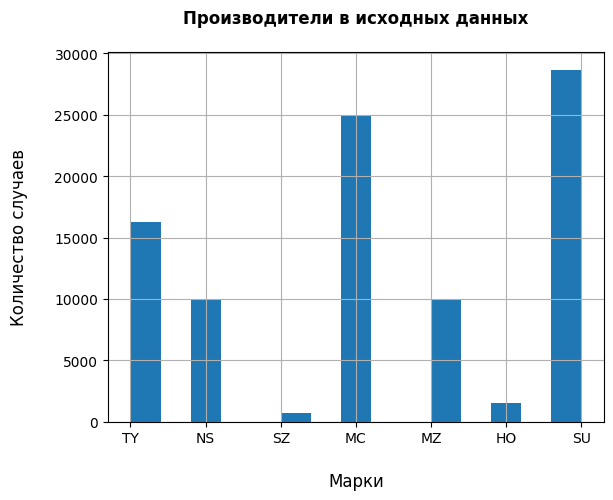

In [32]:
print(pricing_final['Производитель'].describe())
pricing_final['Производитель'].hist(bins=15)
plt.title("Производители в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nМарки", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean        41.265247
std         87.876310
min          0.040000
25%          4.046666
50%         13.077500
75%         38.484000
max       1639.750000
Name: С-ть, dtype: float64


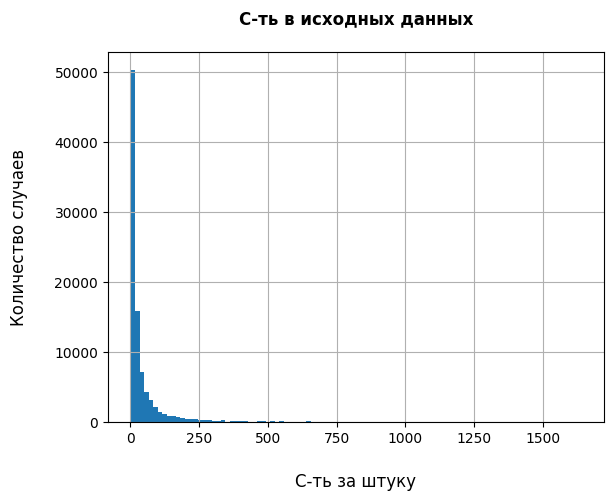

In [34]:
print(pricing_final['С-ть'].describe())
#pricing_final[pricing_final['С-ть']<100]['С-ть'].hist(bins=100)
pricing_final['С-ть'].hist(bins=100)
plt.title("С-ть в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nС-ть за штуку", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         4.624903
std         45.961930
min         -0.928715
25%          0.089003
50%          0.258114
75%          0.528807
max       1498.817229
Name: Маржа, dtype: float64


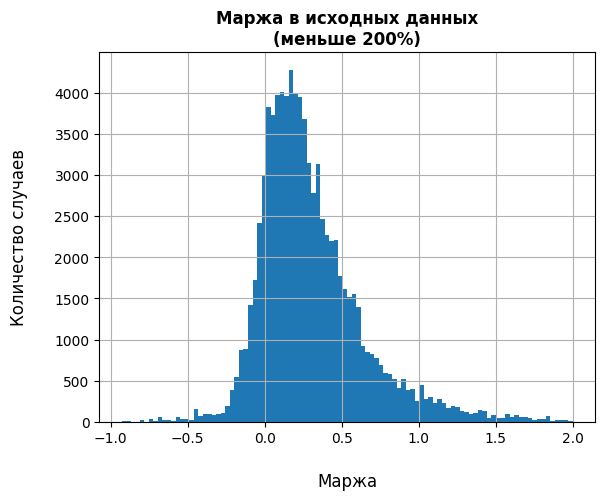

In [35]:
print(pricing_final['Маржа'].describe())
pricing_final[pricing_final['Маржа']<2]['Маржа'].hist(bins=100)
plt.title("Маржа в исходных данных\n(меньше 200%)", fontsize=12, fontweight="bold")
plt.xlabel("\nМаржа", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean        23.063306
std         92.438265
min          1.000000
25%          2.000000
50%          4.000000
75%         13.000000
max       2475.000000
Name: Остаток, dtype: float64


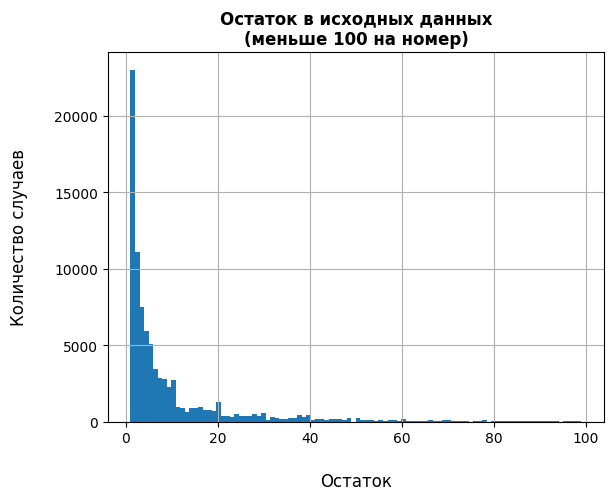

In [36]:
print(pricing_final['Остаток'].describe())
pricing_final[pricing_final['Остаток']<100]['Остаток'].hist(bins=100)
plt.title("Остаток в исходных данных\n(меньше 100 на номер)", fontsize=12, fontweight="bold")
plt.xlabel("\nОстаток", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean       130.543371
std        165.162263
min          0.000000
25%         30.000000
50%         61.000000
75%        155.000000
max       2499.000000
Name: Дней на складе, dtype: float64


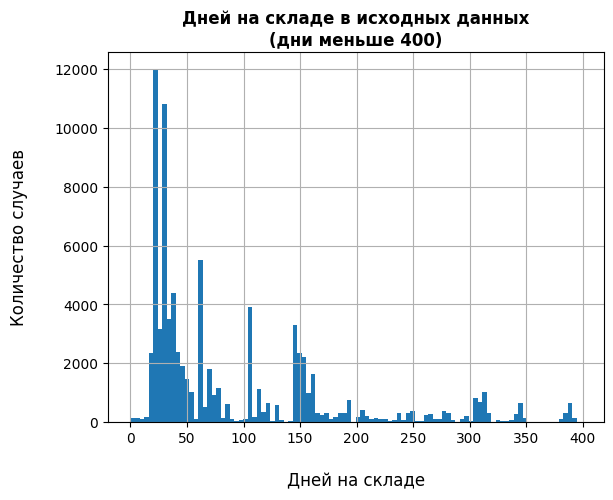

In [37]:
print(pricing_final['Дней на складе'].describe())
pricing_final[pricing_final['Дней на складе']<400]['Дней на складе'].hist(bins=100)
plt.title("Дней на складе в исходных данных\n(дни меньше 400)", fontsize=12, fontweight="bold")
plt.xlabel("\nДней на складе", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean       576.853377
std       1229.185833
min          0.000000
25%          3.000000
50%         16.000000
75%        231.000000
max       3729.000000
Name: Не было продаж, dtype: float64


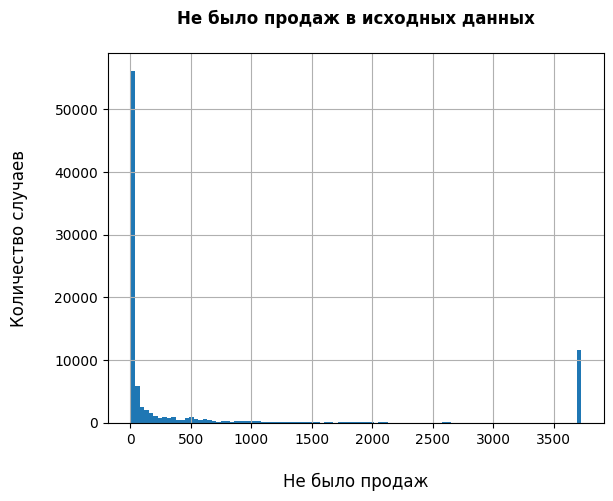

In [38]:
print(pricing_final['Не было продаж'].describe())
pricing_final['Не было продаж'].hist(bins=100)
plt.title("Не было продаж в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nНе было продаж", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         2.195133
std          9.854773
min         -3.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        389.000000
Name: Продажи за период, dtype: float64


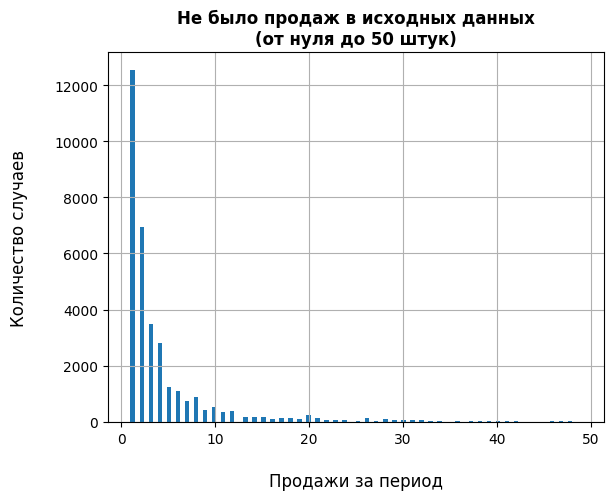

In [39]:
print(pricing_final['Продажи за период'].describe())
pricing_final[(pricing_final['Продажи за период']>0) & (pricing_final['Продажи за период']<50)]['Продажи за период'].hist(bins=100)
plt.title("Не было продаж в исходных данных\n(от нуля до 50 штук)", fontsize=12, fontweight="bold")
plt.xlabel("\nПродажи за период", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         0.230902
std          1.097968
min         -1.000000
25%          0.000000
50%          0.000000
75%          0.142857
max         92.000000
Name: Продажи к остаткам, dtype: float64


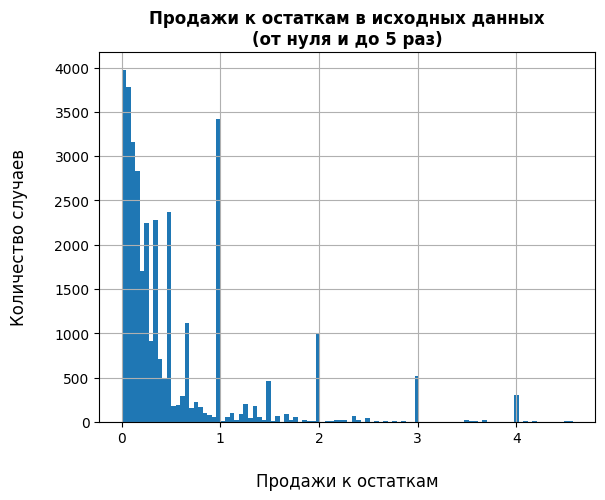

In [40]:
print(pricing_final['Продажи к остаткам'].describe())
pricing_final[(pricing_final['Продажи к остаткам']>0) & (pricing_final['Продажи к остаткам']<5)]['Продажи к остаткам'].hist(bins=100)
plt.title("Продажи к остаткам в исходных данных\n(от нуля и до 5 раз)", fontsize=12, fontweight="bold")
plt.xlabel("\nПродажи к остаткам", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         2.498755
std         11.731803
min          0.000000
25%          0.000000
50%          0.420000
75%          1.500000
max        458.000000
Name: Скорость продаж, dtype: float64


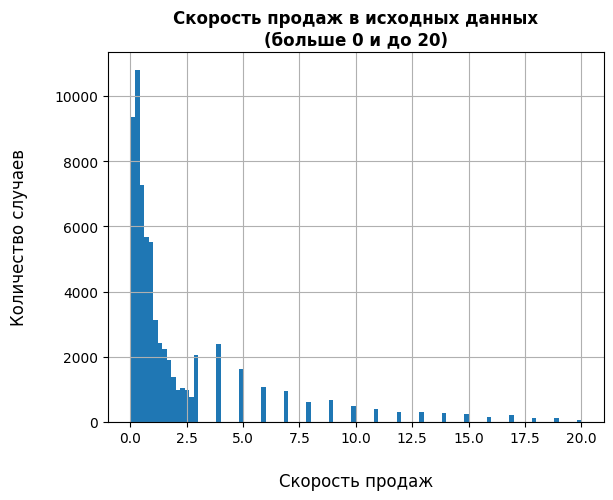

In [41]:
print(pricing_final['Скорость продаж'].describe())
pricing_final[(pricing_final['Скорость продаж']>0) & (pricing_final['Скорость продаж']<=20)]['Скорость продаж'].hist(bins=100)
plt.title("Скорость продаж в исходных данных\n(больше 0 и до 20)", fontsize=12, fontweight="bold")
plt.xlabel("\nСкорость продаж", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         3.016369
std         13.724400
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        350.000000
Name: Средн. скорость, dtype: float64


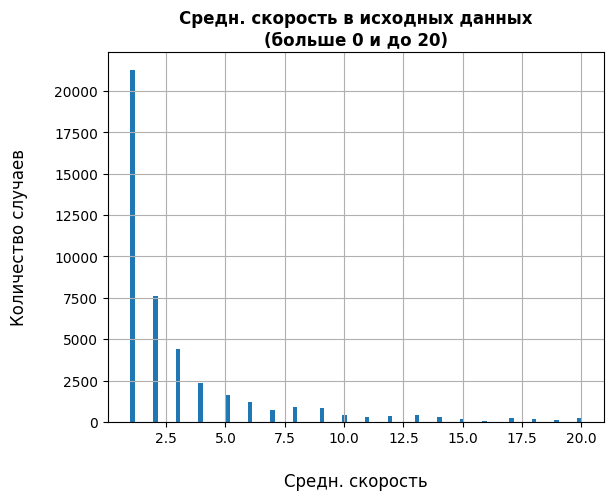

In [42]:
print(pricing_final['Средн. скорость'].describe())
pricing_final[(pricing_final['Средн. скорость']>0) & (pricing_final['Средн. скорость']<=20)]['Средн. скорость'].hist(bins=100)
plt.title("Средн. скорость в исходных данных\n(больше 0 и до 20)", fontsize=12, fontweight="bold")
plt.xlabel("\nСредн. скорость", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         3.016369
std         13.724400
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        350.000000
Name: Средн. скорость, dtype: float64


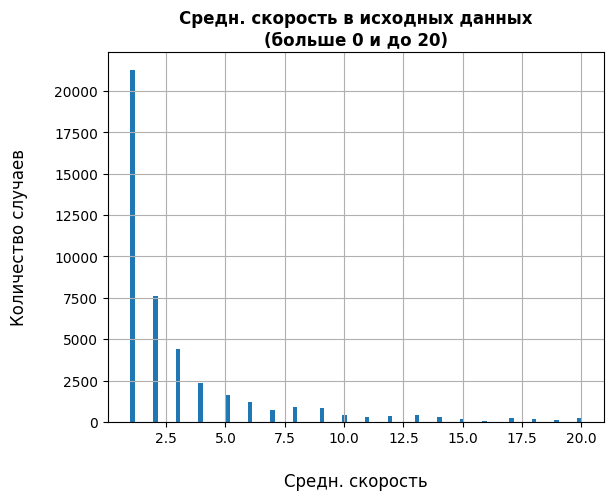

In [43]:
print(pricing_final['Средн. скорость'].describe())
pricing_final[(pricing_final['Средн. скорость']>0) & (pricing_final['Средн. скорость']<=20)]['Средн. скорость'].hist(bins=100)
plt.title("Средн. скорость в исходных данных\n(больше 0 и до 20)", fontsize=12, fontweight="bold")
plt.xlabel("\nСредн. скорость", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean       122.308477
std        157.915129
min          0.000000
25%         30.000000
50%         61.000000
75%        149.000000
max       1921.000000
Name: С момента посл. отпр., dtype: float64


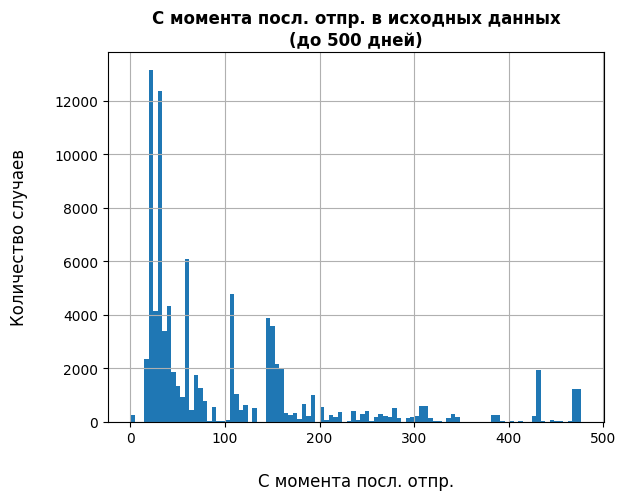

In [44]:
print(pricing_final['С момента посл. отпр.'].describe())
pricing_final[(pricing_final['С момента посл. отпр.']<=500)]['С момента посл. отпр.'].hist(bins=100)
plt.title("С момента посл. отпр. в исходных данных\n(до 500 дней)", fontsize=12, fontweight="bold")
plt.xlabel("\nС момента посл. отпр.", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         8.439014
std         15.911430
min          1.000000
25%          3.000000
50%          5.000000
75%          7.000000
max       1047.000000
Name: Дней назад менялась цена, dtype: float64


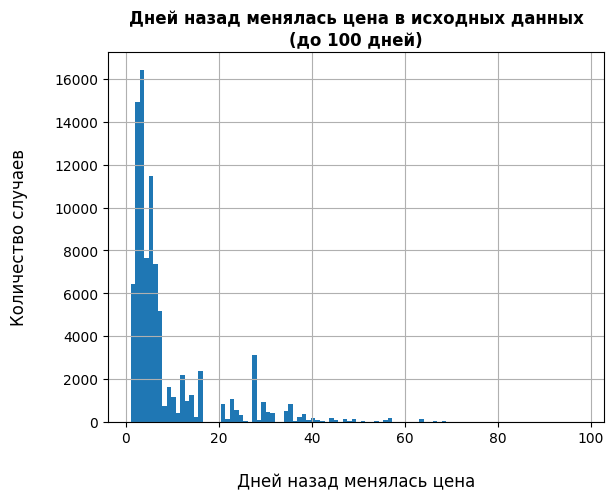

In [45]:
print(pricing_final['Дней назад менялась цена'].describe())
pricing_final[(pricing_final['Дней назад менялась цена']<=100)]['Дней назад менялась цена'].hist(bins=100)
plt.title("Дней назад менялась цена в исходных данных\n(до 100 дней)", fontsize=12, fontweight="bold")
plt.xlabel("\nДней назад менялась цена", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean        -4.694439
std         15.192677
min        -92.000000
25%         -4.000000
50%         -2.000000
75%         -1.000000
max         93.000000
Name: % изменения, dtype: float64


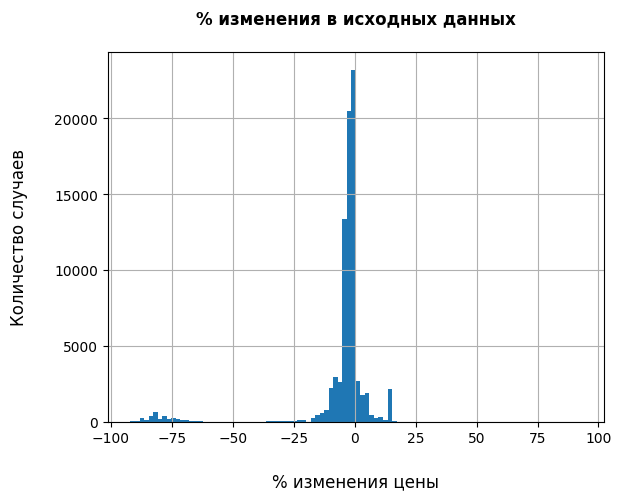

In [46]:
print(pricing_final['% изменения'].describe())
pricing_final[(pricing_final['% изменения']>0) | (pricing_final['% изменения']<0)]['% изменения'].hist(bins=100)
plt.title("% изменения в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\n% изменения цены", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean        40.969416
std         99.559980
min          0.000000
25%          2.520000
50%         10.630000
75%         35.950000
max       1943.170000
Name: Мин. цена, dtype: float64


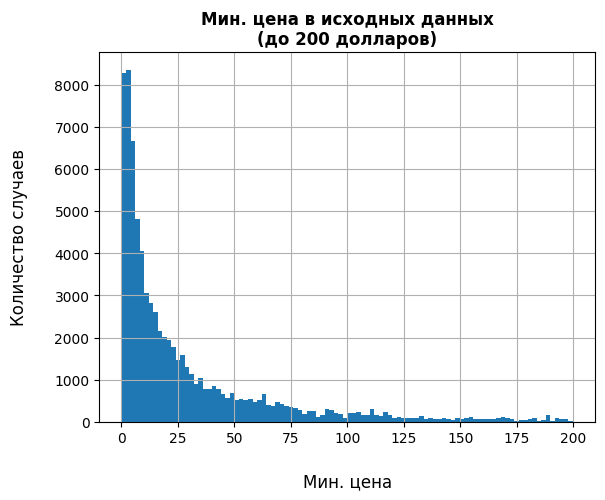

In [47]:
print(pricing_final['Мин. цена'].describe())
pricing_final[(pricing_final['Мин. цена']>0) & (pricing_final['Мин. цена']<200)]['Мин. цена'].hist(bins=100)
plt.title("Мин. цена в исходных данных\n(до 200 долларов)", fontsize=12, fontweight="bold")
plt.xlabel("\nМин. цена", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean        57.897708
std        138.052103
min          0.000000
25%          3.820000
50%         16.335000
75%         52.280000
max       2904.860000
Name: Макс. цена, dtype: float64


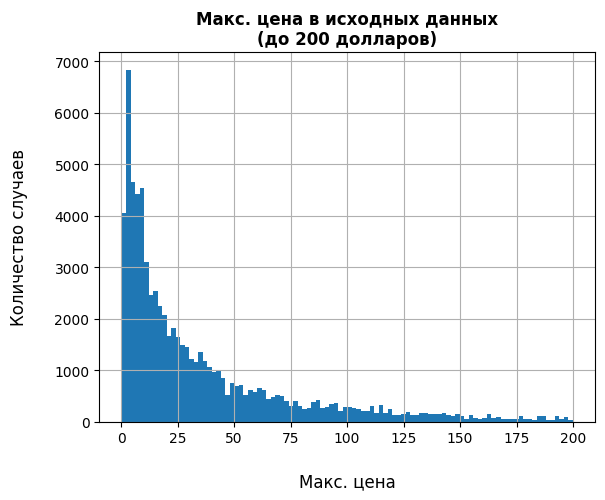

In [48]:
print(pricing_final['Макс. цена'].describe())
pricing_final[(pricing_final['Макс. цена']>0) & (pricing_final['Макс. цена']<200)]['Макс. цена'].hist(bins=100)
plt.title("Макс. цена в исходных данных\n(до 200 долларов)", fontsize=12, fontweight="bold")
plt.xlabel("\nМакс. цена", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean       238.564974
std        492.862693
min          0.040000
25%         23.320000
50%         77.650833
75%        227.809995
max       8072.861183
Name: Общ.  с-ть, dtype: float64


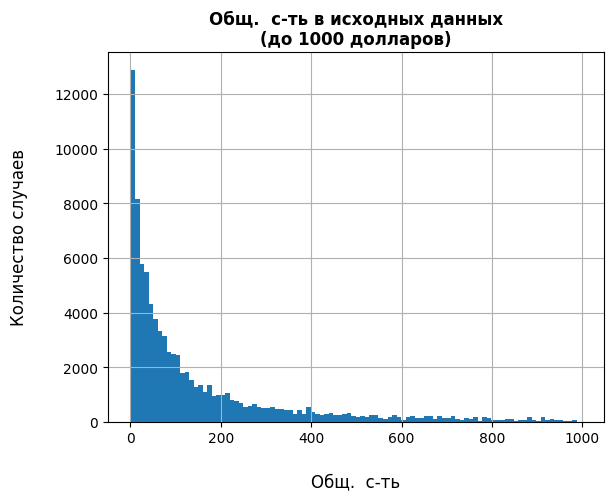

In [49]:
print(pricing_final['Общ.  с-ть'].describe())
pricing_final[(pricing_final['Общ.  с-ть']>0) & (pricing_final['Общ.  с-ть']<1000)]['Общ.  с-ть'].hist(bins=100)
plt.title("Общ.  с-ть в исходных данных\n(до 1000 долларов)", fontsize=12, fontweight="bold")
plt.xlabel("\nОбщ.  с-ть", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

In [50]:
print(pricing_final['Наим.'].describe())

count       92250
unique       2554
top       САЛЬНИК
freq          978
Name: Наим., dtype: object


count        92250
unique           6
top       Не кузов
freq         72181
Name: кузов, dtype: object


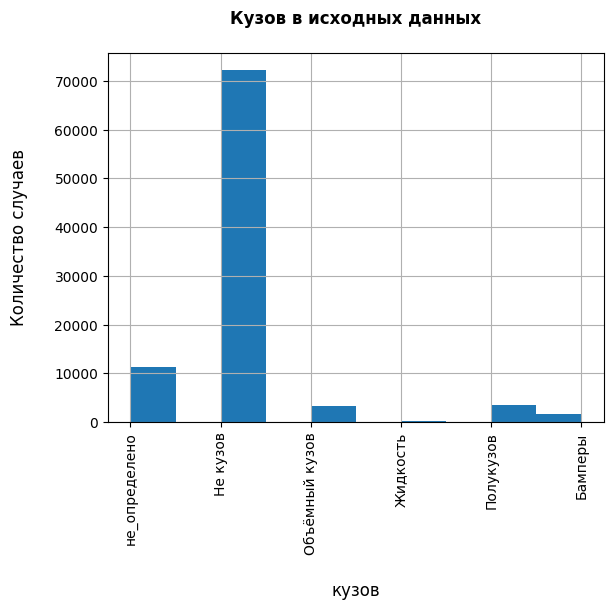

In [51]:
print(pricing_final['кузов'].describe())
pricing_final['кузов'].hist(bins=10)
plt.title("Кузов в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nкузов", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.xticks(rotation=90)
plt.show()

In [52]:
pricing_final['Чей товар новый'].value_counts()

Наш        81712
Города+     6998
MGN+        3540
Name: Чей товар новый, dtype: int64

count     92250
unique        3
top         Наш
freq      81712
Name: Чей товар новый, dtype: object


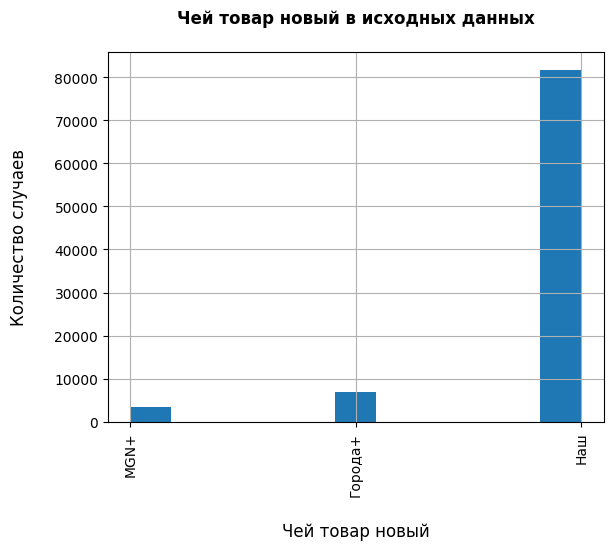

In [53]:
print(pricing_final['Чей товар новый'].describe())
pricing_final['Чей товар новый'].hist(bins=11)
plt.title("Чей товар новый в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nЧей товар новый", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.xticks(rotation=90)
plt.show()

count    92250.000000
mean         5.757875
std          3.512493
min          1.000000
25%          3.000000
50%          5.000000
75%          9.000000
max         12.000000
Name: place, dtype: float64


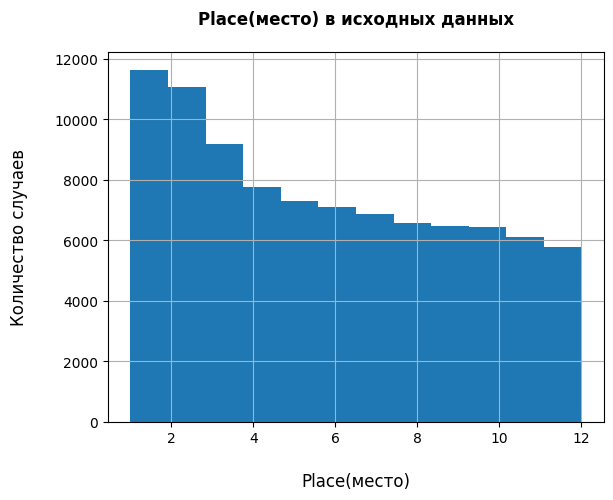

In [54]:
print(pricing_final['place'].describe())
pricing_final['place'].hist(bins=12)
plt.title("Place(место) в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nPlace(место)", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

Сделано в большей степени для проверки себя и для дальнейшего сравнения.

count    92250.000000
mean         4.206472
std          2.760390
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         12.000000
Name: place_final, dtype: float64


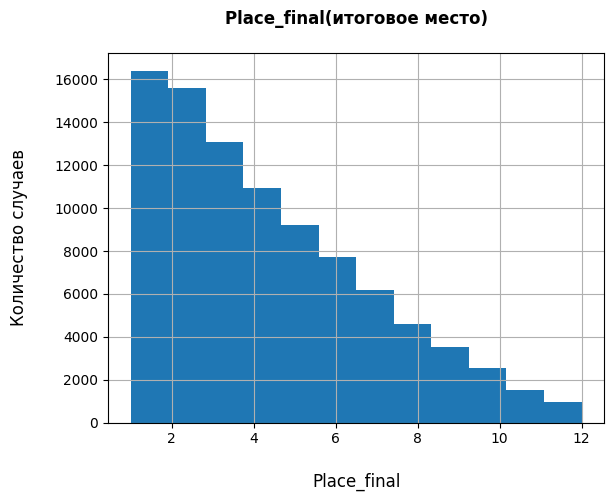

In [55]:
print(pricing_final['place_final'].describe())
pricing_final['place_final'].hist(bins=12)
plt.title("Place_final(итоговое место)\n", fontsize=12, fontweight="bold")
plt.xlabel("\nPlace_final", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

In [56]:
logo_qty = pricing_final['logo'].value_counts()
logo_qty.head(10)

JRQE     16402
RENV      7298
OTHER     4692
OMGA      4523
LYFD      4100
FRWB      3365
SINL      2519
RUDS      2415
SNZR      2364
MZHA      2257
Name: logo, dtype: int64

In [57]:
len(logo_qty)

104

Сотня разных лого.

count    92250.000000
mean         9.766775
std         23.076416
min          0.000000
25%          1.000000
50%          3.000000
75%          6.000000
max        200.000000
Name: qty, dtype: float64


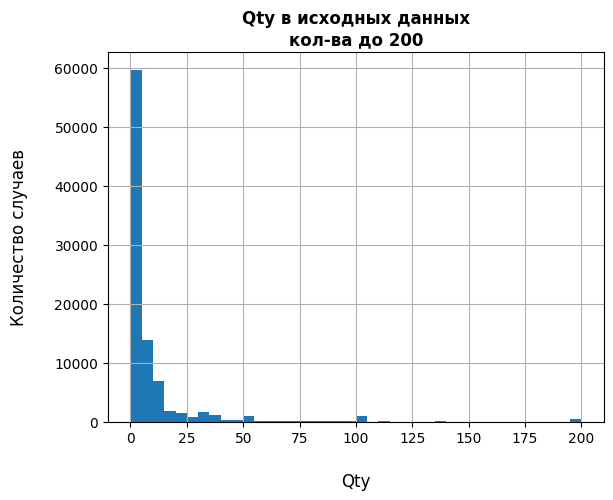

In [58]:
print(pricing_final['qty'].describe())
pricing_final[pricing_final['qty']<201]['qty'].hist(bins=40)
plt.title("Qty в исходных данных\nкол-ва до 200", fontsize=12, fontweight="bold")
plt.xlabel("\nQty", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

Сколько раз встречается лого.  
Поскольку замена на OTHER была сделана после подсчета количества, то значение равное 1 возможно.  

count    92250.000000
mean      4634.911957
std       5806.145632
min          1.000000
25%        645.000000
50%       1648.000000
75%       7298.000000
max      16402.000000
Name: logo_qty, dtype: float64


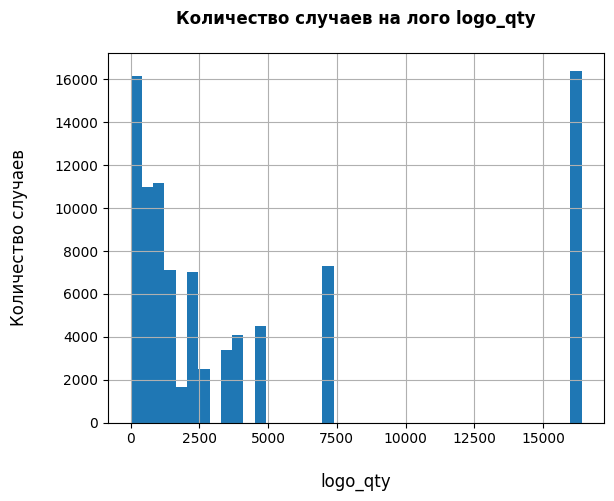

In [59]:
print(pricing_final['logo_qty'].describe())
pricing_final['logo_qty'].hist(bins=40)
plt.title("Количество случаев на лого logo_qty\n", fontsize=12, fontweight="bold")
plt.xlabel("\nlogo_qty", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         2.971642
std          1.510147
min          1.000000
25%          1.000000
50%          4.000000
75%          4.000000
max          6.000000
Name: days, dtype: float64


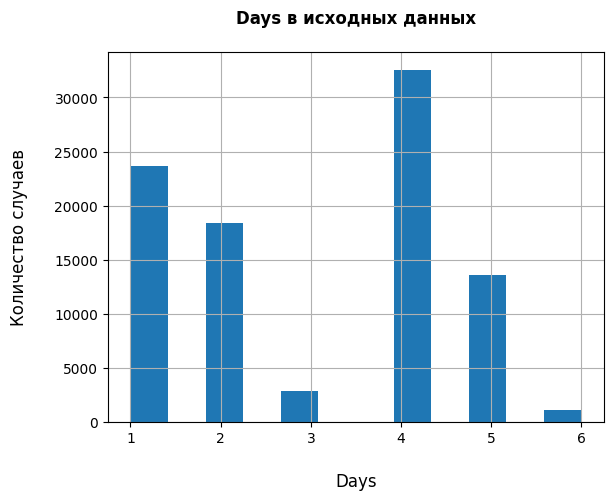

In [60]:
print(pricing_final['days'].describe())
pricing_final['days'].hist(bins=12)
plt.title("Days в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nDays", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    9.225000e+04
mean     9.119289e+03
std      3.020476e+04
min      6.400000e+01
25%      8.820000e+02
50%      2.800000e+03
75%      8.090500e+03
max      3.095053e+06
Name: rub, dtype: float64


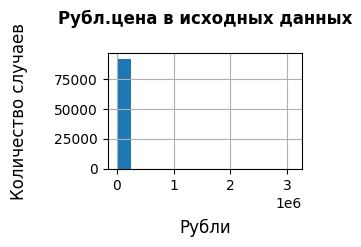

In [61]:
print(pricing_final['rub'].describe())
pricing_final['rub'].hist(bins=12, figsize=(2.5, 1.5))
plt.title("Рубл.цена в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nРубли", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

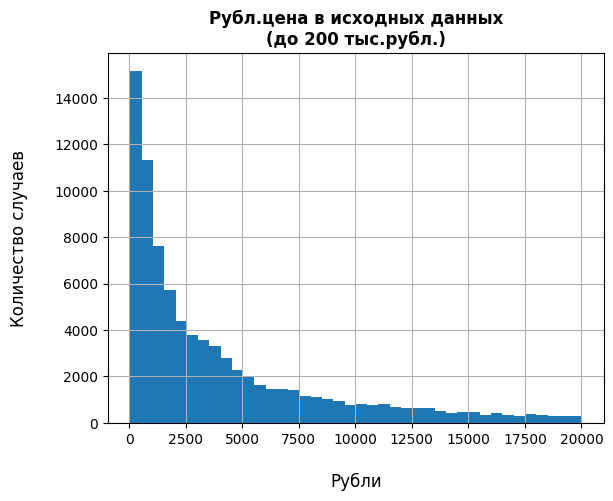

In [62]:
#print(pricing_final['rub'].describe())
pricing_final[pricing_final['rub']<20000]['rub'].hist(bins=40)
plt.title("Рубл.цена в исходных данных\n(до 200 тыс.рубл.)", fontsize=12, fontweight="bold")
plt.xlabel("\nРубли", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean        70.552453
std        244.178483
min          0.313310
25%          6.503216
50%         21.212006
75%         62.100348
max      25557.851509
Name: usd, dtype: float64


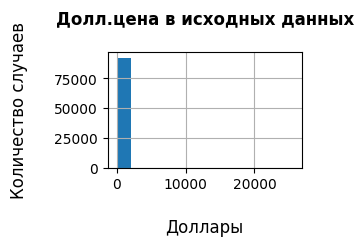

In [63]:
print(pricing_final['usd'].describe())
pricing_final['usd'].hist(bins=12, figsize=(2.5, 1.5))
plt.title("Долл.цена в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nДоллары", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

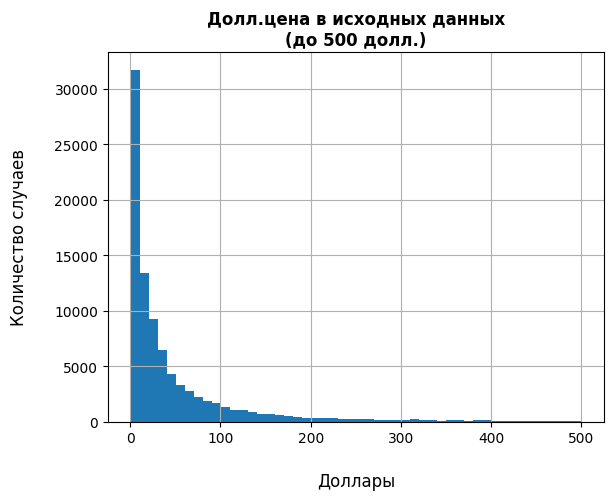

In [64]:
#print(pricing_final['usd'].describe())
pricing_final[pricing_final['usd']<500]['usd'].hist(bins=50)
plt.title("Долл.цена в исходных данных\n(до 500 долл.)", fontsize=12, fontweight="bold")
plt.xlabel("\nДоллары", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         2.080228
std          1.335190
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         12.000000
Name: Место, dtype: float64


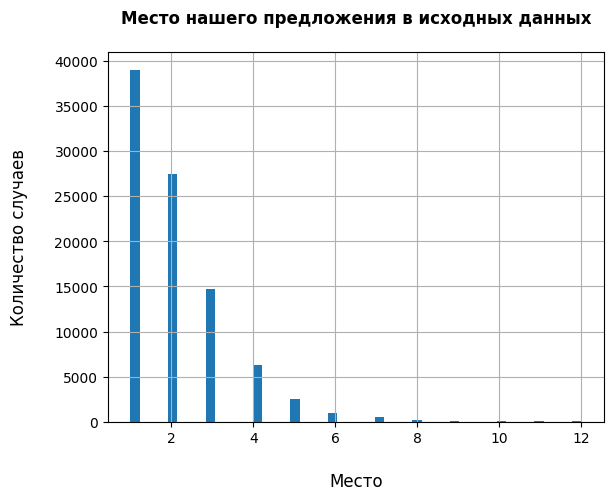

In [65]:
print(pricing_final['Место'].describe())
pricing_final['Место'].hist(bins=offers_num*4)
plt.title("Место нашего предложения в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nМесто", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

Этот признак является вспомогательным для определения, менялась ли цена.

count    92250.000000
mean         1.490190
std          1.018616
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         11.000000
Name: № предложения, dtype: float64


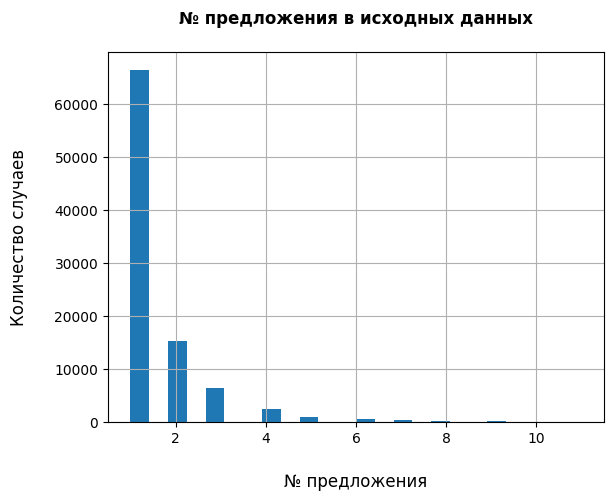

In [66]:
print(pricing_final['№ предложения'].describe())
pricing_final['№ предложения'].hist(bins=offers_num*2)
plt.title("№ предложения в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\n№ предложения", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean        40.993583
std         91.621409
min          0.000000
25%          2.000000
50%          9.000000
75%         33.000000
max       1295.000000
Name: Кол-во перед предл., dtype: float64


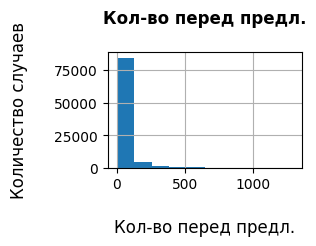

In [67]:
print(pricing_final['Кол-во перед предл.'].describe())
pricing_final['Кол-во перед предл.'].hist(bins=10, figsize=(2.5, 1.5))
plt.title("Кол-во перед предл.\n", fontsize=12, fontweight="bold")
plt.xlabel("\nКол-во перед предл.", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

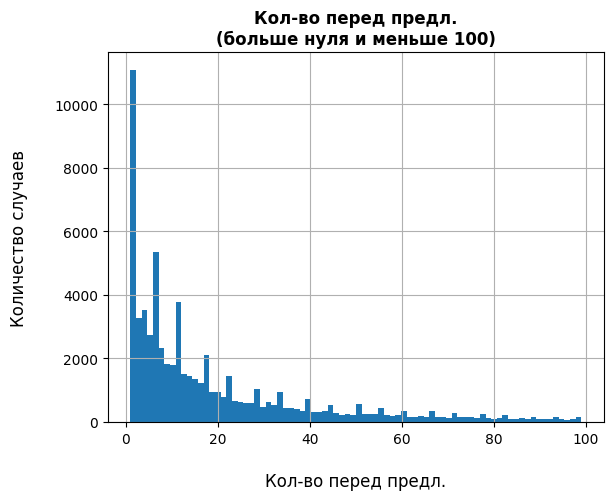

In [68]:
pricing_final[(pricing_final['Кол-во перед предл.']<100)&(pricing_final['Кол-во перед предл.']>0)]['Кол-во перед предл.'].hist(bins=80)
plt.title("Кол-во перед предл.\n(больше нуля и меньше 100)", fontsize=12, fontweight="bold")
plt.xlabel("\nКол-во перед предл.", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

count    92250.000000
mean         5.459124
std         53.472054
min         -0.935207
25%          0.158461
50%          0.371763
75%          0.731525
max       2875.821559
Name: Маржа по предл., dtype: float64


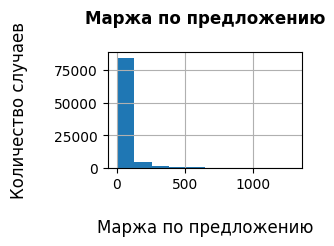

In [69]:
print(pricing_final['Маржа по предл.'].describe())
pricing_final['Кол-во перед предл.'].hist(bins=10, figsize=(2.5, 1.5))
plt.title("Маржа по предложению\n", fontsize=12, fontweight="bold")
plt.xlabel("\nМаржа по предложению", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

### Рассмотрение признаков (github)

#### Дней на складе

count    92250.000000
mean       130.543371
std        165.162263
min          0.000000
25%         30.000000
50%         61.000000
75%        155.000000
max       2499.000000
Name: Дней на складе, dtype: float64


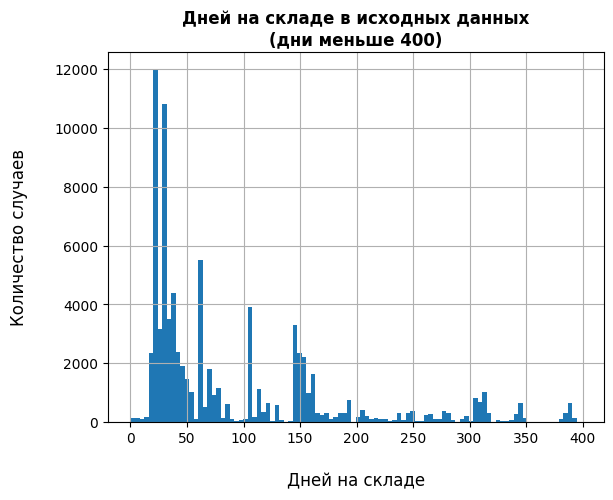

In [70]:
print(pricing_final['Дней на складе'].describe())
pricing_final[pricing_final['Дней на складе']<400]['Дней на складе'].hist(bins=100)
plt.title("Дней на складе в исходных данных\n(дни меньше 400)", fontsize=12, fontweight="bold")
plt.xlabel("\nДней на складе", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Не было продаж

count    92250.000000
mean       576.853377
std       1229.185833
min          0.000000
25%          3.000000
50%         16.000000
75%        231.000000
max       3729.000000
Name: Не было продаж, dtype: float64


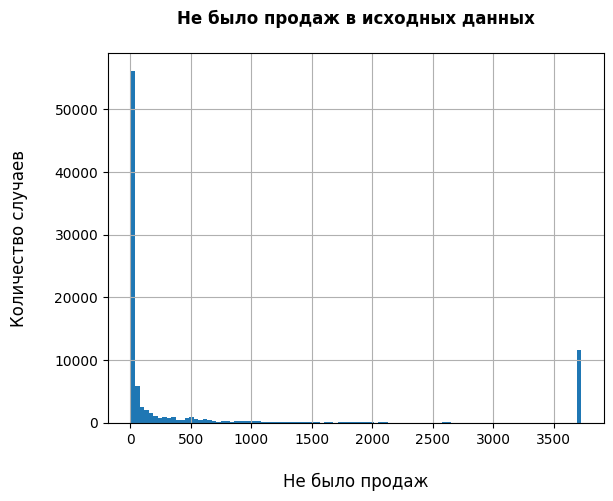

In [71]:
print(pricing_final['Не было продаж'].describe())
pricing_final['Не было продаж'].hist(bins=100)
plt.title("Не было продаж в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nНе было продаж", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### С момента посл. отпр.

count    92250.000000
mean       122.308477
std        157.915129
min          0.000000
25%         30.000000
50%         61.000000
75%        149.000000
max       1921.000000
Name: С момента посл. отпр., dtype: float64


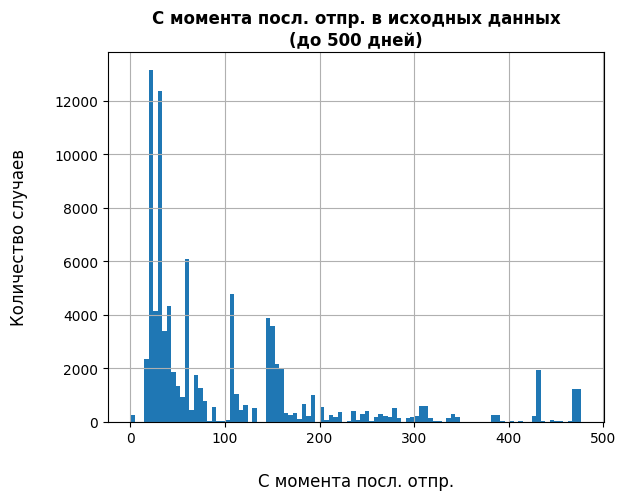

In [72]:
print(pricing_final['С момента посл. отпр.'].describe())
pricing_final[(pricing_final['С момента посл. отпр.']<=500)]['С момента посл. отпр.'].hist(bins=100)
plt.title("С момента посл. отпр. в исходных данных\n(до 500 дней)", fontsize=12, fontweight="bold")
plt.xlabel("\nС момента посл. отпр.", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Дней назад менялась цена

count    92250.000000
mean         8.439014
std         15.911430
min          1.000000
25%          3.000000
50%          5.000000
75%          7.000000
max       1047.000000
Name: Дней назад менялась цена, dtype: float64


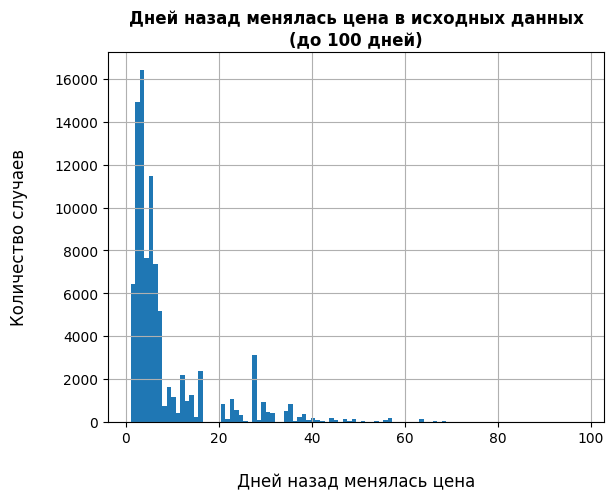

In [73]:
print(pricing_final['Дней назад менялась цена'].describe())
pricing_final[(pricing_final['Дней назад менялась цена']<=100)]['Дней назад менялась цена'].hist(bins=100)
plt.title("Дней назад менялась цена в исходных данных\n(до 100 дней)", fontsize=12, fontweight="bold")
plt.xlabel("\nДней назад менялась цена", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Наим.

In [74]:
print(pricing_final['Наим.'].describe())

count       92250
unique       2554
top       САЛЬНИК
freq          978
Name: Наим., dtype: object


#### Кузов

count        92250
unique           6
top       Не кузов
freq         72181
Name: кузов, dtype: object


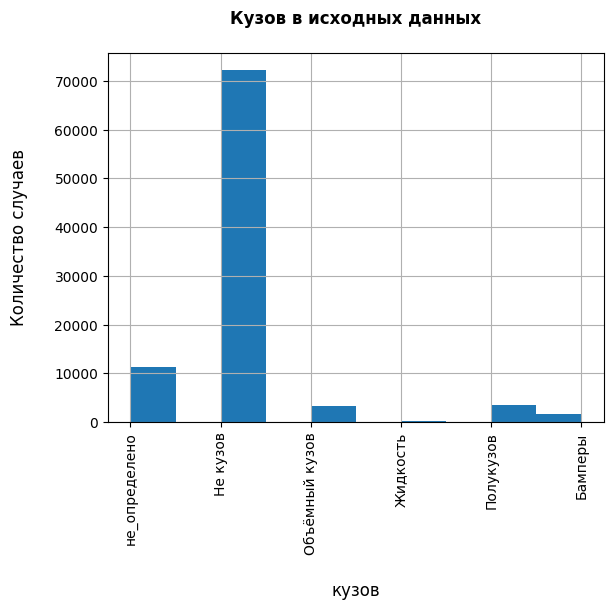

In [75]:
print(pricing_final['кузов'].describe())
pricing_final['кузов'].hist(bins=10)
plt.title("Кузов в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nкузов", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.xticks(rotation=90)
plt.show()

In [76]:
pricing_final['Чей товар новый'].value_counts()

Наш        81712
Города+     6998
MGN+        3540
Name: Чей товар новый, dtype: int64

count     92250
unique        3
top         Наш
freq      81712
Name: Чей товар новый, dtype: object


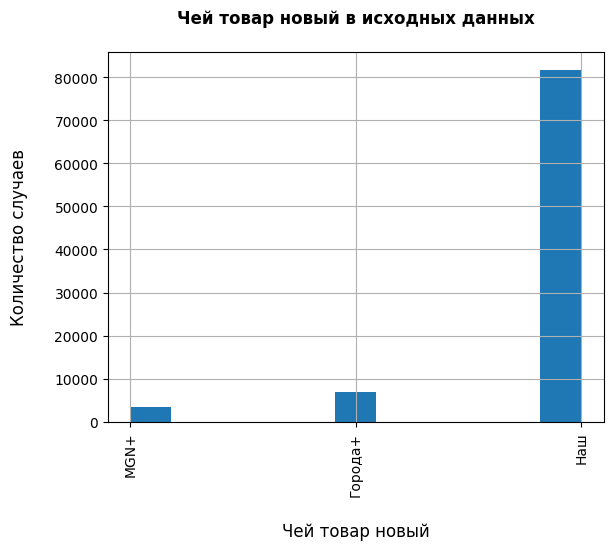

In [77]:
print(pricing_final['Чей товар новый'].describe())
pricing_final['Чей товар новый'].hist(bins=11)
plt.title("Чей товар новый в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nЧей товар новый", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.xticks(rotation=90)
plt.show()

#### Place

count    92250.000000
mean         5.757875
std          3.512493
min          1.000000
25%          3.000000
50%          5.000000
75%          9.000000
max         12.000000
Name: place, dtype: float64


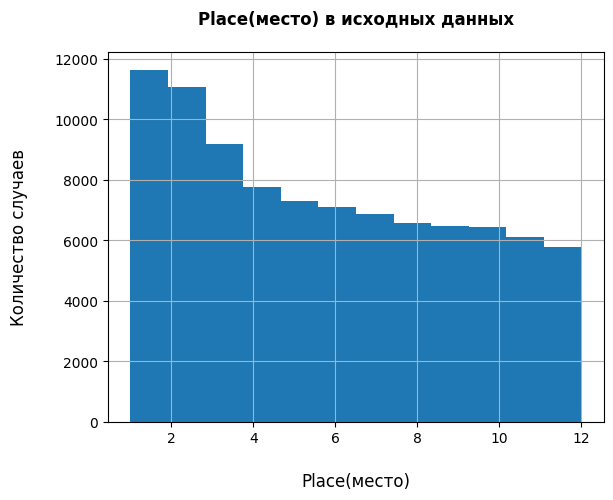

In [78]:
print(pricing_final['place'].describe())
pricing_final['place'].hist(bins=12)
plt.title("Place(место) в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nPlace(место)", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

Сделано в большей степени для проверки себя и для дальнейшего сравнения.

#### Place_final (новый признак)

count    92250.000000
mean         4.206472
std          2.760390
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         12.000000
Name: place_final, dtype: float64


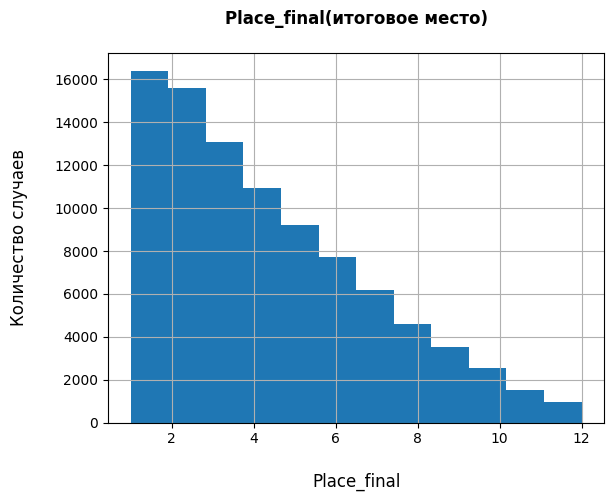

In [79]:
print(pricing_final['place_final'].describe())
pricing_final['place_final'].hist(bins=12)
plt.title("Place_final(итоговое место)\n", fontsize=12, fontweight="bold")
plt.xlabel("\nPlace_final", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Logo

In [80]:
logo_qty = pricing_final['logo'].value_counts()
#logo_qty.head(10)

In [81]:
len(logo_qty)

104

Сотня разных лого.

#### Days

count    92250.000000
mean         2.971642
std          1.510147
min          1.000000
25%          1.000000
50%          4.000000
75%          4.000000
max          6.000000
Name: days, dtype: float64


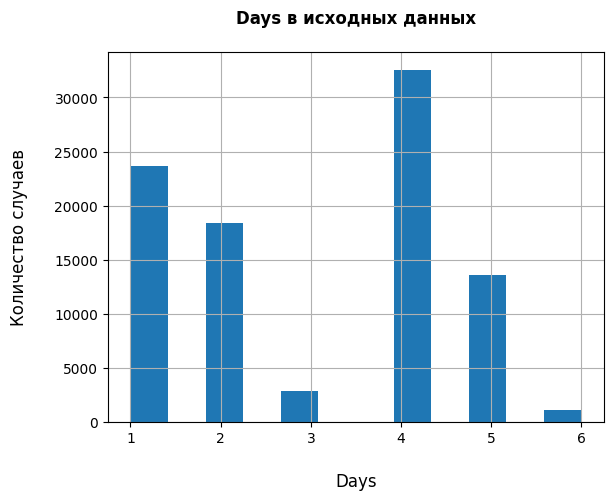

In [82]:
print(pricing_final['days'].describe())
pricing_final['days'].hist(bins=12)
plt.title("Days в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nDays", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### Место (нашего предложения)

count    92250.000000
mean         2.080228
std          1.335190
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         12.000000
Name: Место, dtype: float64


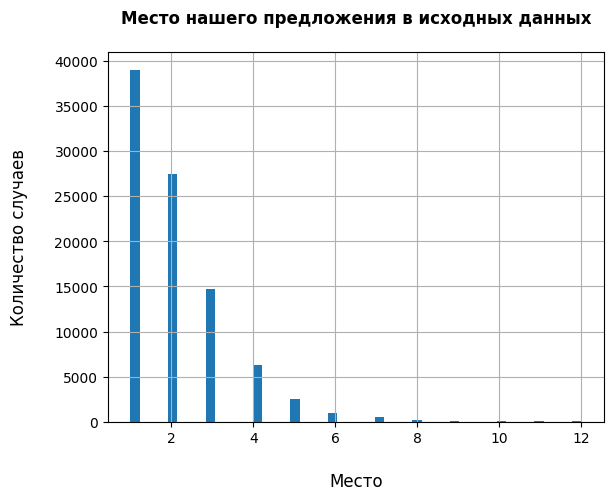

In [83]:
print(pricing_final['Место'].describe())
pricing_final['Место'].hist(bins=offers_num*4)
plt.title("Место нашего предложения в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\nМесто", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

#### № предложения

Этот признак является вспомогательным для определения, менялась ли цена.

count    92250.000000
mean         1.490190
std          1.018616
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         11.000000
Name: № предложения, dtype: float64


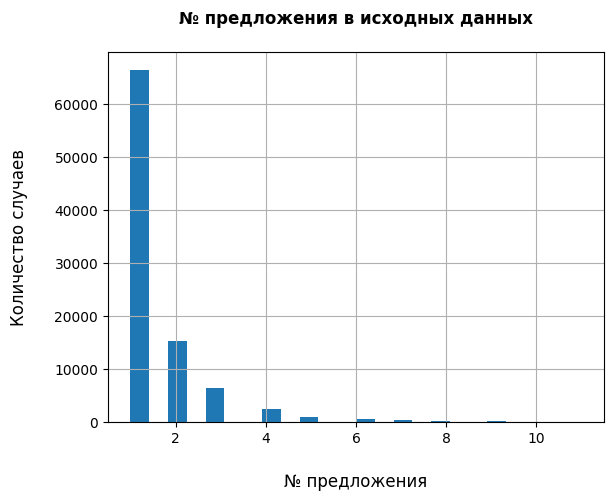

In [84]:
print(pricing_final['№ предложения'].describe())
pricing_final['№ предложения'].hist(bins=offers_num*2)
plt.title("№ предложения в исходных данных\n", fontsize=12, fontweight="bold")
plt.xlabel("\n№ предложения", fontsize=12)#, fontweight="bold")
plt.ylabel("Количество случаев\n",  fontsize=12)#, fontweight="bold")
plt.show()

## Создание main, датасета для моделей

In [85]:
def making_main_dataset(pricing_final):
    main = pricing_final[['Производитель', 'Цена', 'С-ть', 'Маржа', 'Остаток',
           'Дней на складе', 'Не было продаж', 'Продажи за период',
           'Продажи к остаткам', 'Скорость продаж', 'Средн. скорость',
           'С момента посл. отпр.', 'Дней назад менялась цена', '% изменения',
           'Мин. цена', 'Макс. цена', 'Общ.  с-ть',
           'кузов', 'Чей товар новый', 'file',
           'logo', 'qty', 'days', 'rub', 'usd',
           'place_final', 'logo_qty', 'Кол-во перед предл.', 'Маржа по предл.',
           'usd_our', 'Разница с ценой','Выбор места']].copy()

    main['main_key'] = pricing_final['key_final'] + ' ' + pricing_final['logo']
    main.set_index(['main_key'], inplace = True)

    main.drop('Маржа', axis=1, inplace=True)
    main.drop('С момента посл. отпр.', axis=1, inplace=True)
    main.drop('usd_our', axis=1, inplace=True)
    main.drop('Мин. цена', axis=1, inplace=True)
    main.drop('logo_qty', axis=1, inplace=True)
    main.drop('rub', axis=1, inplace=True)

    return main
    

In [86]:
main = making_main_dataset(pricing_final)

In [88]:
main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92250 entries, TY_0023406014_file_1 1 JRQE to MC_MD378593_file_8 12 TOSG
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Производитель             92250 non-null  object 
 1   Цена                      92250 non-null  float64
 2   С-ть                      92250 non-null  float64
 3   Остаток                   92250 non-null  int64  
 4   Дней на складе            92250 non-null  int64  
 5   Не было продаж            92250 non-null  int64  
 6   Продажи за период         92250 non-null  int64  
 7   Продажи к остаткам        92250 non-null  float64
 8   Скорость продаж           92250 non-null  float64
 9   Средн. скорость           92250 non-null  int64  
 10  Дней назад менялась цена  92250 non-null  int64  
 11  % изменения               92250 non-null  int64  
 12  Макс. цена                92250 non-null  float64
 13  Общ.  с-ть         

In [90]:
#main.head()

## phik матрица

In [91]:
interval_cols = ['Цена', 'С-ть', 'Маржа', 'Остаток',
       'Дней на складе', 'Не было продаж', 'Продажи за период',
       'Продажи к остаткам', 'Скорость продаж', 'Средн. скорость',
       'С момента посл. отпр.', 'Дней назад менялась цена', '% изменения',
       'Мин. цена', 'Макс. цена', 'Общ.  с-ть', 
       'qty', 'days', 'rub', 'usd',
       'place_final', 'logo_qty', 'Кол-во перед предл.', 'Маржа по предл.',
       'usd_our', 'Разница с ценой']

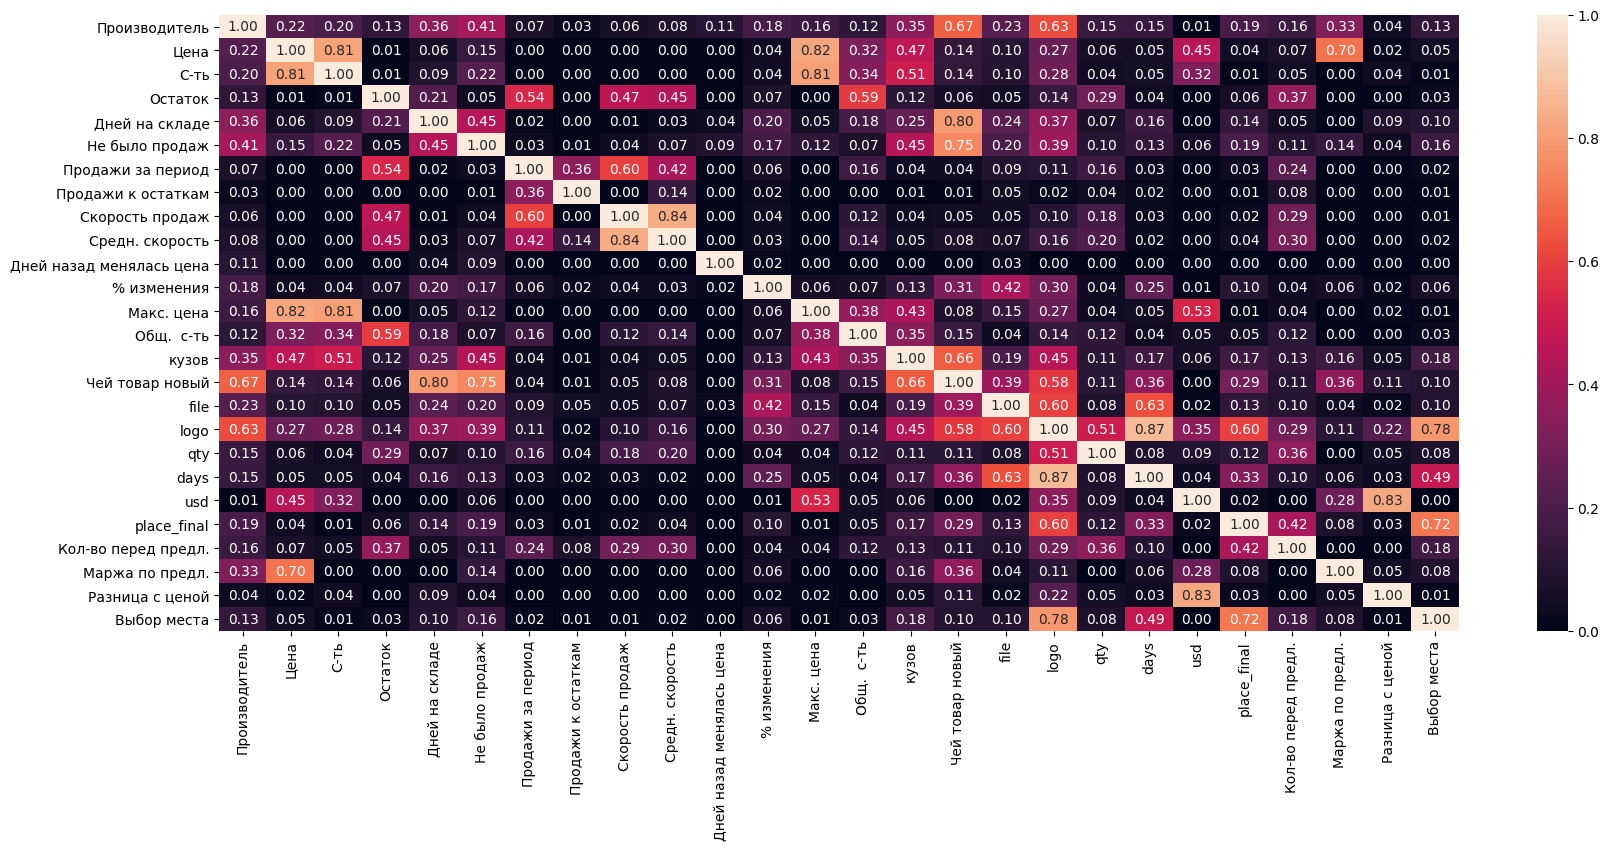

In [92]:
ig, ax = plt.subplots(figsize=(20, 8))
#sns.heatmap(main.phik_matrix(interval_cols=interval_cols), annot=True, fmt='.2f') 
sns.heatmap(main[main['file']!='to_price'].phik_matrix(interval_cols=interval_cols), annot=True, fmt='.2f') 
display()

## Создание X_train, X_test, y_train, y_test и X_predict

In [93]:
X = main.drop(columns=['Выбор места', 'file'])
y = main['Выбор места']
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
random_state=RANDOM_STATE
)

## Модели

### Логистическая регрессия

In [94]:
cat_col_names = ['Производитель', 'кузов', 'Чей товар новый','logo']

In [95]:
ord_col_names = ['days', 'place_final']

In [96]:
num_col_names = ['Цена', 'С-ть', 'Остаток', 'Дней на складе',
       'Не было продаж', 'Продажи за период', 'Продажи к остаткам',
       'Скорость продаж', 'Средн. скорость', 'Дней назад менялась цена',
       '% изменения', 'Макс. цена', 'Общ.  с-ть', 
       'qty', 'usd', 'Кол-во перед предл.',
       'Маржа по предл.', 'Разница с ценой']

In [97]:
scaler = StandardScaler()

In [98]:
X_train_scaled = scaler.fit_transform(X_train[num_col_names]) 

In [99]:
X_test_scaled = scaler.transform(X_test[num_col_names]) 

In [100]:
encoder = OneHotEncoder(drop='first',sparse=False,handle_unknown = 'error')

In [101]:
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])

In [102]:
X_test_ohe = encoder.transform(X_test[cat_col_names])

In [103]:
encoder_col_names = encoder.get_feature_names() 

In [104]:
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=encoder_col_names)

In [105]:
X_test_ohe_df = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

In [106]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=num_col_names)

In [107]:
X_train_df = pd.concat([X_train_ohe_df, X_train_scaled_df,X_train[ord_col_names].reset_index(drop=True)], axis=1)

In [108]:
X_test_df = pd.concat([X_test_ohe_df, X_test_scaled_df,X_test[ord_col_names].reset_index(drop=True)], axis=1)

In [109]:
model_lgr = LogisticRegression(solver='lbfgs', max_iter=400)

In [110]:
result_lgr = cross_val_score(model_lgr, X_train_df, y_train,  scoring='accuracy', cv=10) 

In [111]:
print(f'accuracy логистической регрессии на кросс-валидации равен: {result_lgr.mean():.3f}')

accuracy логистической регрессии на кросс-валидации равен: 0.919


### DummyClassifier

Для сравнения добавим DummyClassifier со стратегий most_frequent, наиболее часто встречающиеся.

In [112]:
dummy_most_frequent = DummyClassifier(strategy = 'most_frequent').fit(X_train_scaled, y_train)
predict_dummy_most_frequent = dummy_most_frequent.predict(X_test_scaled) 
result_dummy_most_frequent = accuracy_score(y_test, predict_dummy_most_frequent)
print(f'accuracy DummyClassifier на тестовой выборке равен: {result_dummy_most_frequent:.5f}')

accuracy DummyClassifier на тестовой выборке равен: 0.81984


### Модель LightGBM

In [113]:
X_train_light = X_train.copy() 
X_test_light = X_test.copy() 

In [114]:
X_train_light[cat_col_names+ord_col_names] = X_train_light[cat_col_names+ord_col_names].astype('category')

In [115]:
X_test_light[cat_col_names+ord_col_names] = X_test_light[cat_col_names+ord_col_names].astype('category')

In [116]:
parameters_light =  {
    'num_leaves': distributions.IntDistribution(31, 100),
    'learning_rate': distributions.FloatDistribution(0.01, 0.5) #(0.1, 0.5) 
} 

In [117]:
model_light = LGBMClassifier(random_state=RANDOM_STATE)

In [118]:
oscv_light = OptunaSearchCV(
    model_light,
    parameters_light,
    random_state=RANDOM_STATE,
    n_trials = 10,
    cv = 5,
    scoring = 'accuracy'
)

C:\Users\pogar\AppData\Local\Temp\ipykernel_6876\4056963137.py:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv_light = OptunaSearchCV(


In [119]:
oscv_light.fit(X_train_light, y_train)

[I 2025-09-26 19:09:57,271] A new study created in memory with name: no-name-4e4fd33f-e2fc-4cca-a872-4219c95a2f3e


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9797, number of negative: 45552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007422 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3914
[LightGBM] [Info] Number of data points in the train set: 55349, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.177004 -> initscore=-1.536778
[LightGBM] [Info] Start training from score -1.536778
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9797, number of negative: 45552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007365 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3911
[LightGBM] [Info] Number of data points in the train set: 55349, number of used f

[I 2025-09-26 19:10:06,731] Trial 0 finished with value: 0.956653715340782 and parameters: {'num_leaves': 62, 'learning_rate': 0.41798969583433027}. Best is trial 0 with value: 0.956653715340782.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9797, number of negative: 45552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007308 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3914
[LightGBM] [Info] Number of data points in the train set: 55349, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.177004 -> initscore=-1.536778
[LightGBM] [Info] Start training from score -1.536778
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9797, number of negative: 45552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007232 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3911
[LightGBM] [Info] Number of data points in the train set: 55349, number of used f

[I 2025-09-26 19:10:12,098] Trial 1 finished with value: 0.9616980099365348 and parameters: {'num_leaves': 35, 'learning_rate': 0.166529153009486}. Best is trial 1 with value: 0.9616980099365348.


...

[I 2025-09-26 19:11:03,902] Trial 8 finished with value: 0.9506699243143306 and parameters: {'num_leaves': 90, 'learning_rate': 0.48713392792056365}. Best is trial 3 with value: 0.9638371445095956.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9797, number of negative: 45552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003782 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3914
[LightGBM] [Info] Number of data points in the train set: 55349, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.177004 -> initscore=-1.536778
[LightGBM] [Info] Start training from score -1.536778
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 9797, number of negative: 45552
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3911
[LightGBM] [Info] Number of data points in the train set: 55349, number of used f

[I 2025-09-26 19:11:09,021] Trial 9 finished with value: 0.9544856853016135 and parameters: {'num_leaves': 63, 'learning_rate': 0.4766662391254943}. Best is trial 3 with value: 0.9638371445095956.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 12247, number of negative: 56940
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009369 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3922
[LightGBM] [Info] Number of data points in the train set: 69187, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.177013 -> initscore=-1.536717
[LightGBM] [Info] Start training from score -1.536717


OptunaSearchCV(cv=5, estimator=LGBMClassifier(random_state=42), n_jobs=1,
               param_distributions={'learning_rate': FloatDistribution(high=0.5, log=False, low=0.01, step=None),
                                    'num_leaves': IntDistribution(high=100, log=False, low=31, step=1)},
               random_state=42, scoring='accuracy')

In [120]:
print(f'Лучшие параметры LightGBM {oscv_light.best_params_}')

Лучшие параметры LightGBM {'num_leaves': 45, 'learning_rate': 0.09170595060520594}


In [122]:
print(f'accuracy LightGMB на кросс-валидации равен: {oscv_light.best_score_:.5f}')

accuracy LightGMB на кросс-валидации равен: 0.96384


### Модель CatBoost

In [123]:
model_cb = CatBoostClassifier(random_state=RANDOM_STATE)

In [124]:
cat_features = cat_col_names + ord_col_names

In [125]:
parameters_cb =  {
    'iterations': distributions.IntDistribution(100, 300),  #(150, 150)  
    'depth' : distributions.IntDistribution(1, 10), #(1, 5)
    'min_data_in_leaf' : distributions.IntDistribution(1, 200) #(1, 100)
} 

In [126]:
oscv_cb = OptunaSearchCV(
    model_cb,
    parameters_cb,
    random_state=RANDOM_STATE,
    n_trials = 3,
    cv = 5,
    scoring = 'accuracy'
)

C:\Users\pogar\AppData\Local\Temp\ipykernel_6876\4209249060.py:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv_cb = OptunaSearchCV(


In [127]:
oscv_cb.fit(X_train, y_train, cat_features=cat_features, verbose=10)

[I 2025-09-26 19:19:10,125] A new study created in memory with name: no-name-3a11c74c-71f6-4823-88c3-3f610d807b71


Learning rate set to 0.260936
0:	learn: 0.2574098	total: 368ms	remaining: 1m 9s
10:	learn: 0.0909034	total: 2.15s	remaining: 35.1s
20:	learn: 0.0778017	total: 4.06s	remaining: 32.8s
30:	learn: 0.0721322	total: 5.99s	remaining: 30.9s
40:	learn: 0.0656784	total: 7.61s	remaining: 27.8s
50:	learn: 0.0595092	total: 9.35s	remaining: 25.7s
60:	learn: 0.0532336	total: 11.1s	remaining: 23.6s
70:	learn: 0.0497732	total: 12.9s	remaining: 21.7s
80:	learn: 0.0457799	total: 14.7s	remaining: 20s
90:	learn: 0.0427644	total: 16.9s	remaining: 18.6s
100:	learn: 0.0401939	total: 19.4s	remaining: 17.3s
110:	learn: 0.0376744	total: 21.8s	remaining: 15.7s
120:	learn: 0.0351451	total: 24.5s	remaining: 14.2s
130:	learn: 0.0325514	total: 26.7s	remaining: 12.2s
140:	learn: 0.0304704	total: 29.1s	remaining: 10.3s
150:	learn: 0.0290450	total: 31.3s	remaining: 8.3s
160:	learn: 0.0268002	total: 33.6s	remaining: 6.26s
170:	learn: 0.0256579	total: 35.8s	remaining: 4.18s
180:	learn: 0.0240179	total: 38.1s	remaining: 2.

[I 2025-09-26 19:22:19,045] Trial 0 finished with value: 0.9635046993727258 and parameters: {'iterations': 191, 'depth': 9, 'min_data_in_leaf': 14}. Best is trial 0 with value: 0.9635046993727258.


190:	learn: 0.0235206	total: 32.7s	remaining: 0us
Learning rate set to 0.300075
0:	learn: 0.2336352	total: 85.9ms	remaining: 14s
10:	learn: 0.1063467	total: 927ms	remaining: 12.9s
20:	learn: 0.0957347	total: 1.79s	remaining: 12.2s
30:	learn: 0.0924676	total: 2.58s	remaining: 11.1s
40:	learn: 0.0888305	total: 3.48s	remaining: 10.4s
50:	learn: 0.0869288	total: 4.33s	remaining: 9.6s
60:	learn: 0.0848471	total: 5.16s	remaining: 8.71s
70:	learn: 0.0830294	total: 6.05s	remaining: 7.93s
80:	learn: 0.0812960	total: 6.97s	remaining: 7.15s
90:	learn: 0.0796092	total: 7.84s	remaining: 6.29s
100:	learn: 0.0780551	total: 8.74s	remaining: 5.45s
110:	learn: 0.0764388	total: 9.55s	remaining: 4.56s
120:	learn: 0.0751912	total: 10.4s	remaining: 3.69s
130:	learn: 0.0738844	total: 11.1s	remaining: 2.8s
140:	learn: 0.0727861	total: 11.9s	remaining: 1.94s
150:	learn: 0.0719304	total: 12.7s	remaining: 1.09s
160:	learn: 0.0709289	total: 13.5s	remaining: 251ms
163:	learn: 0.0704694	total: 13.7s	remaining: 0us


[I 2025-09-26 19:23:34,148] Trial 1 finished with value: 0.9630999999028601 and parameters: {'iterations': 164, 'depth': 5, 'min_data_in_leaf': 60}. Best is trial 0 with value: 0.9635046993727258.


163:	learn: 0.0688879	total: 15s	remaining: 0us
Learning rate set to 0.342447
0:	learn: 0.3521467	total: 43.4ms	remaining: 6.12s
10:	learn: 0.1245372	total: 543ms	remaining: 6.46s
20:	learn: 0.1180929	total: 1.08s	remaining: 6.24s
30:	learn: 0.1118779	total: 1.55s	remaining: 5.55s
40:	learn: 0.1088745	total: 2.13s	remaining: 5.26s
50:	learn: 0.1054212	total: 2.61s	remaining: 4.66s
60:	learn: 0.1036104	total: 3.09s	remaining: 4.1s
70:	learn: 0.1017764	total: 3.55s	remaining: 3.55s
80:	learn: 0.1004704	total: 4.06s	remaining: 3.06s
90:	learn: 0.0996535	total: 4.52s	remaining: 2.54s
100:	learn: 0.0984463	total: 5.03s	remaining: 2.04s
110:	learn: 0.0977922	total: 5.52s	remaining: 1.54s
120:	learn: 0.0970297	total: 6s	remaining: 1.04s
130:	learn: 0.0962995	total: 6.47s	remaining: 543ms
140:	learn: 0.0957804	total: 6.94s	remaining: 49.3ms
141:	learn: 0.0957804	total: 7s	remaining: 0us
Learning rate set to 0.342447
0:	learn: 0.3472014	total: 49.5ms	remaining: 6.98s
10:	learn: 0.1224772	total:

[I 2025-09-26 19:24:12,475] Trial 2 finished with value: 0.9586772137346259 and parameters: {'iterations': 142, 'depth': 2, 'min_data_in_leaf': 36}. Best is trial 0 with value: 0.9635046993727258.


140:	learn: 0.0954391	total: 6.83s	remaining: 48.4ms
141:	learn: 0.0952034	total: 6.87s	remaining: 0us
Learning rate set to 0.287023
0:	learn: 0.2393107	total: 248ms	remaining: 47.2s
10:	learn: 0.0885235	total: 2.94s	remaining: 48.1s
20:	learn: 0.0759123	total: 4.89s	remaining: 39.6s
30:	learn: 0.0691519	total: 6.91s	remaining: 35.7s
40:	learn: 0.0635122	total: 8.92s	remaining: 32.6s
50:	learn: 0.0573983	total: 10.8s	remaining: 29.7s
60:	learn: 0.0523946	total: 12.8s	remaining: 27.2s
70:	learn: 0.0486859	total: 14.7s	remaining: 24.8s
80:	learn: 0.0454363	total: 16.6s	remaining: 22.5s
90:	learn: 0.0424228	total: 18.5s	remaining: 20.3s
100:	learn: 0.0399476	total: 20.4s	remaining: 18.1s
110:	learn: 0.0374119	total: 22.6s	remaining: 16.3s
120:	learn: 0.0350489	total: 24.8s	remaining: 14.4s
130:	learn: 0.0331031	total: 26.8s	remaining: 12.3s
140:	learn: 0.0306746	total: 28.7s	remaining: 10.2s
150:	learn: 0.0289958	total: 30.6s	remaining: 8.11s
160:	learn: 0.0272623	total: 32.5s	remaining: 

OptunaSearchCV(cv=5,
               estimator=<catboost.core.CatBoostClassifier object at 0x000001819B815490>,
               n_jobs=1, n_trials=3,
               param_distributions={'depth': IntDistribution(high=10, log=False, low=1, step=1),
                                    'iterations': IntDistribution(high=300, log=False, low=100, step=1),
                                    'min_data_in_leaf': IntDistribution(high=200, log=False, low=1, step=1)},
               random_state=42, scoring='accuracy')

In [128]:
print(f'Лучшие параметры CatBoost {oscv_cb.best_params_}')

Лучшие параметры CatBoost {'iterations': 191, 'depth': 9, 'min_data_in_leaf': 14}


In [129]:
print(f'accuracy CatBoost на кросс-валидации равен: {oscv_cb.best_score_:.5f}')

accuracy CatBoost на кросс-валидации равен: 0.96350


### Модель дерева решений

In [130]:
cols_ordinal = cat_col_names + ord_col_names

In [131]:
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)

In [132]:
X_train_ord = X_train.copy()

In [133]:
X_train_ord[cols_ordinal] = ordinal_encoder.fit_transform(X_train_ord[cols_ordinal])

In [134]:
X_test_ord = X_test.copy()

In [135]:
X_test_ord[cols_ordinal] = ordinal_encoder.transform(X_test_ord[cols_ordinal])

In [136]:
parameters_tree =  {
    'max_depth': distributions.IntDistribution(2, 150), #(2, 100)
    'max_features': distributions.IntDistribution(2, 10) #(2, 50)
} 

In [137]:
model_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

In [138]:
oscv_tree = OptunaSearchCV(
    model_tree,
    parameters_tree,
    random_state=RANDOM_STATE,
    n_trials = 50,
    cv = 5,
    scoring = 'accuracy'
)

C:\Users\pogar\AppData\Local\Temp\ipykernel_6876\118112337.py:1: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  oscv_tree = OptunaSearchCV(


In [139]:
oscv_tree.fit(X_train_ord, y_train)

[I 2025-09-26 19:25:29,184] A new study created in memory with name: no-name-62b0b466-7ecd-41a2-84ce-ad90c1a0ad8f
[I 2025-09-26 19:25:30,625] Trial 0 finished with value: 0.9414484821696518 and parameters: {'max_depth': 69, 'max_features': 9}. Best is trial 0 with value: 0.9414484821696518.
[I 2025-09-26 19:25:31,621] Trial 1 finished with value: 0.9444115521992824 and parameters: {'max_depth': 12, 'max_features': 4}. Best is trial 1 with value: 0.9444115521992824.
[I 2025-09-26 19:25:32,684] Trial 2 finished with value: 0.9361295772388791 and parameters: {'max_depth': 74, 'max_features': 4}. Best is trial 1 with value: 0.9444115521992824.
[I 2025-09-26 19:25:33,684] Trial 3 finished with value: 0.9328775817945946 and parameters: {'max_depth': 33, 'max_features': 3}. Best is trial 1 with value: 0.9444115521992824.
[I 2025-09-26 19:25:34,898] Trial 4 finished with value: 0.9361295772388791 and parameters: {'max_depth': 28, 'max_features': 4}. Best is trial 1 with value: 0.94441155219928

OptunaSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
               n_jobs=1, n_trials=50,
               param_distributions={'max_depth': IntDistribution(high=150, log=False, low=2, step=1),
                                    'max_features': IntDistribution(high=10, log=False, low=2, step=1)},
               random_state=42, scoring='accuracy')

In [140]:
print(f'Лучшие параметры дерева решений {oscv_tree.best_params_}')

Лучшие параметры дерева решений {'max_depth': 8, 'max_features': 9}


In [141]:
print(f'accuracy дерева решений на кросс-валидации равен: {oscv_tree.best_score_:.5f}')

accuracy дерева решений на кросс-валидации равен: 0.95120


### Выбор лучшей модели

Все модели проверялись на кросс-валидации.  

Для лучшей модели, проверенной на кросс-валидации, это LightGBM, проверим результат на тестовой выборке.  

In [142]:
predictions_light = oscv_light.predict(X_test_light)

In [143]:
result_light_final = accuracy_score(y_test, predictions_light)

In [144]:
print(f'accuracy LightGMB на тестовой выборке равен: {result_light_final:.5f}')

accuracy LightGMB на тестовой выборке равен: 0.96132


In [145]:
df = pd.DataFrame({'Модель': ["Лог.регрессия","LightGBM","CatBoost","Дерево решений"],
                   'accuracy на кросс.валидации': [round(result_lgr.mean(),3),round(oscv_light.best_score_,3),round(oscv_cb.best_score_,3),round(oscv_tree.best_score_,3)],
                    'accuracy на тест. выборке' : ["-",round(result_light_final,3),"-","-"]
                  })

In [146]:
df

,Модель,accuracy на кросс.валидации,accuracy на тест. выборке
0,Лог.регрессия,0.919,-
1,LightGBM,0.964,0.961
2,CatBoost,0.964,-
3,Дерево решений,0.951,-


Лучшей моделью оказался LightGBM с показателем accuracy 0,961 на тестовой выборке.

## Загрузка файла на проценку

In [147]:
to_price = pd.DataFrame()

In [148]:
for file in glob(files_folder + "/to_price/*.xlsm"):
    print(files_folder + "*.xlsm")
    print(file)
    temp_file = pd.read_excel(file,engine='openpyxl')
    temp_file['file'] = 'to_price'#file_num
    to_price = to_price.append(temp_file)

C:/Users/pogar/jypyter projects/pricing*.xlsm
C:/Users/pogar/jypyter projects/pricing/to_price\шаблон проценки 18.09.25.xlsm


C:\Users\pogar\anaconda3\envs\practicum\lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [149]:
delete_unused_columns(to_price)

In [150]:
to_price = left_and_right_parts(to_price)

In [151]:
to_price = pricing_preprocessing(to_price, False)

In [152]:
to_price = adding_new_features(to_price)

In [153]:
main_to_price = making_main_dataset(to_price)

In [154]:
X_predict = main_to_price.drop(columns=['Выбор места', 'file'])

In [155]:
y_predict = main_to_price['Выбор места']

In [156]:
X_predict_light = X_predict.copy() 

In [157]:
X_predict_light[cat_col_names+ord_col_names] = X_predict_light[cat_col_names+ord_col_names].astype('category')

In [158]:
predictions_result = oscv_light.predict(X_predict_light)

In [159]:
predictions_proba_result = oscv_light.predict_proba(X_predict_light)[:,1]

In [160]:
X_predict_light['result'] = predictions_result

In [161]:
X_predict_light['proba'] = predictions_proba_result

In [162]:
X_predict_light.to_excel('X_predict_light_final.xlsx')#, index=False)

## Выводы

Лучшей моделью оказался LightGBM с показателем accuracy 0,961 на тестовой выборке.  
Полученный результат достаточно высок.  
Увеличение метрики возможно при большем количестве исходных данных.  
Следующий шаг - это переход от проценки только по местам к возможным более сложным действиям..